In [193]:
# Load Required Packages
library(phyloseq)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(magrittr)
library(tibble)
library(microbiome)
library(ANCOMBC)
library(lme4)
library(patchwork)
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/Figures"

In [194]:
library("DESeq2")

In [199]:
# Load phyloseq
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.cleaned.nomock.rds")

In [200]:
library(phyloseq)

rename_asvs <- function(ps) {
  old_names <- taxa_names(ps)
  new_names <- paste0("ASV", seq_along(old_names))
  
  # Convert taxonomy to data frame
  tax_df <- as.data.frame(tax_table(ps))
  
  # Remove existing Sequence column if it exists
  if ("Sequence" %in% colnames(tax_df)) {
    tax_df <- tax_df[, !colnames(tax_df) %in% "Sequence", drop = FALSE]
  }
  
  # Add Sequence column at the beginning
  tax_df <- cbind(Sequence = old_names, tax_df)
  
  # Reassign to phyloseq object
  tax_table(ps) <- as.matrix(tax_df)
  taxa_names(ps) <- new_names
  
  return(ps)
}


In [201]:
ps <- rename_asvs(ps)


In [205]:

# -------------------------
# Extract and format metadata
# -------------------------
meta <- data.frame(sample_data(ps))
meta$ExtractionDate <- as.Date(meta$ExtractionDate, format = "%m/%d/%Y")
meta$ExtractionDate_cat <- as.factor(meta$ExtractionDate)
meta$Parity_numeric <- as.numeric(as.character(meta$Parity))
meta$Parity_Group <- factor(ifelse(meta$Parity_numeric <= 3, "Group1", "Group2"))
meta$BCS <- as.numeric(as.character(meta$BCS))
meta$BCS_Group <- factor(cut(meta$BCS,
                             breaks = c(-Inf, 2.5, 3.5, Inf),
                             labels = c("Low", "Medium", "High"),
                             right = TRUE))
meta$Fibrinogen_InflamStat <- factor(meta$Fibrinogen_InflamStat, levels = c("Normal", "Elevated"))
meta$Haptoglobin_InflamStat <- factor(meta$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))
meta$Haptoglobin_InflamStat <- relevel(meta$Haptoglobin_InflamStat, ref = "Normal")

# Check
str(meta[, c("Haptoglobin_InflamStat", "BCS_Group", "Parity_Group", "ExtractionDate_cat")])

meta$Cow_ID <- factor(meta$Cow_ID)


# Create Haptoglobin mean column
if (all(c("Haptoglobin_1DIM", "Haptoglobin_3DIM") %in% colnames(meta))) {
  meta$Haptoglobin_Mean <- rowMeans(
    meta[, c("Haptoglobin_1DIM", "Haptoglobin_3DIM")],
    na.rm = TRUE
  )
} else if ("Haptoglobin_1DIM" %in% colnames(meta)) {
  meta$Haptoglobin_Mean <- meta$Haptoglobin_1DIM
} else {
  stop("No Haptoglobin columns found in metadata")
}

# Make numeric
meta$Haptoglobin_Mean <- as.numeric(meta$Haptoglobin_Mean)


'data.frame':	142 obs. of  4 variables:
 $ Haptoglobin_InflamStat: Factor w/ 2 levels "Normal","Elevated": 1 1 1 1 2 2 1 1 1 1 ...
 $ BCS_Group             : Factor w/ 3 levels "Low","Medium",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ Parity_Group          : Factor w/ 2 levels "Group1","Group2": 1 1 1 1 1 1 1 1 1 1 ...
 $ ExtractionDate_cat    : Factor w/ 6 levels "24-12-24","24-12-27",..: 1 2 1 2 1 2 1 2 1 2 ...


In [203]:
sample_data(ps) <- sample_data(meta)


In [204]:
# Ensure correct orientation: taxa x samples
if (taxa_are_rows(ps)) {
  otu <- as(otu_table(ps), "matrix")   
} else {
  otu <- t(as(otu_table(ps), "matrix"))
}

# Align samples between counts and metadata
meta <- data.frame(sample_data(ps))
common_samples <- intersect(colnames(otu), rownames(meta))
otu  <- otu[, common_samples]
meta <- meta[common_samples, ]

# Check dimensions
cat("Samples in counts:", ncol(otu), "\n")
cat("Samples in metadata:", nrow(meta), "\n")


Samples in counts: 142 
Samples in metadata: 142 


In [197]:
colnames(meta)

[1] "X"                                        
 [2] "Sample_ID"                                
 [3] "Corrected_Sample_ID"                      
 [4] "Cow_ID"                                   
 [5] "DIM_Collected"                            
 [6] "Date_Collected"                           
 [7] "Date_Recieved"                            
 [8] "Farm"                                     
 [9] "Sample_Type"                              
[10] "Sex"                                      
[11] "BCS"                                      
[12] "Parity"                                   
[13] "Housing_type"                             
[14] "Fibrinogen_1DIM"                          
[15] "Fibrinogen_3DIM"                          
[16] "Fibrinogen_7DIM"                          
[17] "Fibrinogen_InflamStat"                    
[18] "FIBRINOGEN_MEAN"                          
[19] "MeanFibrinogen_InflamStat"                
[20] "Haptoglobin_1DIM"                         
[21] "Haptoglobin_3DIM"                         
[22] "Haptoglobin_InflamStat"                   
[23] "ExtractionDate"                           
[24] "ExtractionKit"                            
[25] "DNAElutionVolume"                         
[26] "DNAYield_ng"                              
[27] "qpcr_16s_copies_ul"                       
[28] "LinkerPrimerSequence"                     
[29] "ReverseSequence"                          
[30] "general.rawsamplename"                    
[31] "general.readlength"                       
[32] "general.readlengthr2"                     
[33] "general.runname"                          
[34] "general.samplename"                       
[35] "subsample.rawreads"                       
[36] "subsample.subsampledreads"                
[37] "fastqc.meanreadqualityR1"                 
[38] "fastqc.meanreadqualityR2"                 
[39] "fastqc.meanreadqualityR2.1"               
[40] "fastqc.pct.deduplicated"                  
[41] "fastqc.pct.dimer"                         
[42] "fastqc.pct.gc"                            
[43] "fastqc.sequencelength"                    
[44] "fastqc.totalsequences"                    
[45] "dedupmetric.PCRduplication"               
[46] "dedupmetric.Tileduplication"              
[47] "fastqspeciesscreen.pct.Adapters"          
[48] "fastqspeciesscreen.pct.Chloroplast"       
[49] "fastqspeciesscreen.pct.ITS"               
[50] "fastqspeciesscreen.pct.Mitochondria"      
[51] "fastqspeciesscreen.pct.PhiX"              
[52] "fastqspeciesscreen.pct.Synthetic_16S_mock"
[53] "fastqspeciesscreen.pct.Synthetic_ITS_mock"
[54] "fastqspeciesscreen.pct.Unaligned"         
[55] "fastqspeciesscreen.pct.Vectors"           
[56] "fastqspeciesscreen.pct.ecoli"             
[57] "fastqspeciesscreen.pct.human"             
[58] "fastqspeciesscreen.pct.mouse"             
[59] "fastqspeciesscreen.pct.rRNA"              
[60] "input"                                    
[61] "filtered"                                 
[62] "denoisedF"                                
[63] "denoisedR"                                
[64] "merged"                                   
[65] "nonchim"                                  
[66] "Sample_Type2"                             
[67] "is.neg"                                   
[68] "ExtractionDate_cat"                       
[69] "Parity_numeric"                           
[70] "Parity_Group"                             
[71] "BCS_Group"                                
[72] "Haptoglobin_Mean"

In [206]:
# Convert to factor and set reference
meta$Haptoglobin_InflamStat <- factor(meta$Haptoglobin_InflamStat, levels = c("Normal", "Elevated"))
# Check levels
levels(meta$Haptoglobin_InflamStat)
#> [1] "Normal" "Elevated"

dds_Hapto <- DESeqDataSetFromMatrix(
  countData = otu,
  colData   = meta,
  design    = ~ Haptoglobin_InflamStat + BCS_Group + Parity_Group + ExtractionDate_cat
)

dds_Hapto <- estimateSizeFactors(dds_Hapto, type = "poscounts")  
dds_Hapto$meta <- relevel(dds_Hapto$Haptoglobin_InflamStat, ref = "Normal")
dds_Hapto <- DESeq(dds_Hapto)

alpha = 0.01

# Get results
result_Hapto <- results(dds_Hapto, alpha = alpha)


[1] "Normal"   "Elevated"

converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

  No

In [207]:
saveRDS(dds_Hapto, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/dds_Hapto.rds")


In [208]:
saveRDS(result_Hapto,file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Deseq_result_Hapto.rds")


In [209]:
dds_Hapto

class: DESeqDataSet 
dim: 21727 142 
metadata(1): version
assays(6): counts mu ... replaceCounts replaceCooks
rownames(21727): ASV1 ASV2 ... ASV21726 ASV21727
rowData names(55): baseMean baseVar ... maxCooks replace
colnames(142): 1165D1LM 1165D3LM ... 9967D1LM 9967D3LM
colData names(75): X Sample_ID ... meta replaceable

In [210]:
result_Hapto <- results(dds_Hapto)
head(results(dds_Hapto, tidy=TRUE))

,row,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ASV1,10755.578,3.04825316,1.4023861,2.1736190,0.029733759,0.062606081
2,ASV2,9001.815,1.83898051,0.5705590,3.2231204,0.001268022,0.004767282
3,ASV3,3969.784,0.07423008,0.6622596,0.1120861,0.910755159,0.954184396
4,ASV4,1956.707,0.36479770,1.2609034,0.2893145,0.772340689,0.857151160
5,ASV5,1973.058,1.31435981,1.1158121,1.1779401,0.238820495,0.361463309
6,ASV6,1675.948,1.58969102,1.2756581,1.2461733,0.212700773,0.324400777


In [211]:
summary(result_Hapto)


out of 2687 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 250, 9.3%
LFC < 0 (down)     : 612, 23%
outliers [1]       : 1171, 44%
low counts [2]     : 1021, 38%
(mean count < 1)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [212]:
# Convert to data.frame
result_Hapto <- as.data.frame(result_Hapto)

# Order by adjusted p-value (padj / q-value), then by absolute log2FoldChange
result_Hapto <- result_Hapto[order(result_Hapto$padj, -abs(result_Hapto$log2FoldChange)), ]

# Check top rows
head(result_Hapto) 

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ASV228,304.9610,-27.81191,3.287793,-8.459143,2.693505e-17,4.083354e-14
ASV140,360.1467,21.11686,2.759752,7.651721,1.983074e-14,1.503170e-11
ASV100,420.7759,26.50408,3.606142,7.349705,1.986444e-13,1.003816e-10
ASV281,213.4894,-30.00000,4.158785,-7.213645,5.447360e-13,1.519495e-10
ASV457,178.4109,-29.93919,4.170174,-7.179363,7.003702e-13,1.519495e-10
ASV484,172.6837,-29.86765,4.160350,-7.179120,7.016139e-13,1.519495e-10


In [213]:

# Run DESeq2 results
result_Hapto <- results(dds_Hapto, tidy = TRUE)

# Convert to data frame
result_Hapto_df <- as.data.frame(result_Hapto)
if ("row" %in% colnames(result_Hapto_df)) {
  # If tidy=TRUE produced 'row' column
  result_Hapto_df <- result_Hapto_df %>%
    dplyr::rename(ASV = row)
} else {
  # If tidy=FALSE or no 'row' column
  result_Hapto_df$ASV <- rownames(result_Hapto_df)
}

# Extract taxonomy table from phyloseq object
taxa_df <- as.data.frame(tax_table(ps)) %>%
  rownames_to_column("ASV")

# Merge results with taxonomy
result_Hapto_annot <- result_Hapto_df %>%
  left_join(taxa_df, by = "ASV")

# Sort by abundance (baseMean), effect size (log2FoldChange), and significance (padj)
result_Hapto_sorted <- result_Hapto_annot %>%
  arrange(desc(baseMean), desc(abs(log2FoldChange)), padj)

write.csv(
  result_Hapto_sorted,
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/result_Haptoo_annotated_sorted.csv",
  row.names = FALSE
)


# Preview top rows
head(result_Hapto_sorted, 20)


,ASV,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASV1,10755.578,3.04825316,1.4023861,2.17361902,0.029733759,0.062606081,CAAGCCTGATGCAGCGACGCCGCGTGCGGGATGGAGGCCTTCGGGTTGTAAACCGCTTTTGTTCAAGGGCAAGGCACGGTTTCGGCCGTGTTGAGTGGATTGTTCGAATAAGCACCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGATTTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAG,Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
2,ASV2,9001.815,1.83898051,0.5705590,3.22312041,0.001268022,0.004767282,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGCCAGAAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTTTTGGAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTAGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAG,Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium,NA
3,ASV3,3969.784,0.07423008,0.6622596,0.11208607,0.910755159,0.954184396,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGATTTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGTCAGGAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTCTTGAAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTTGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAG,Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,NA,NA
4,ASV10,1990.416,0.43010733,1.2530536,0.34324735,0.731412386,0.818922583,AAAGCCTGAACCAGCCAAGTCGCGTGAAGGATGAAGGTTCTATGGATTGTAAACTTCTTTTGTCTGAGGGTAAAAAAGCGGACGTGTCCGTTCTTGCAAGTATCAGACGAATAAGCATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGGTTGCTAAGTCAGTGGTAAAAGCGTGTGGCTCAACCATACCAAGCCATTGAAACTGGTGATCTTGAGTGTAAACGAGGTAGGCGGAATGTGACGTGTAGCGGTGAAATGCTTAGATATGTCACAGAACCCCGATTGCGAAGGCAGCTTACCAGCATACAACTGACGCTGAGGCACGAAAG,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidales RF16 group,NA,NA
5,ASV5,1973.058,1.31435981,1.1158121,1.17794008,0.238820495,0.361463309,AAAGCCTGACCGAGCAACGCCGCGTGAATGATGAAGGCCTTCGGGTTGTAAAATTCTGTTATAAGGGAAGAACGACTTTAGTAGGAAATGGCTAAAGTGTGACGGTACCTTATGAGAAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGCGCGCAGGTGGTTGATTAAGTCTGATGTGAAAGCCCACGGCTTAACCGTGGAGGGTCATTGGAAACTGGTCGACTTGAGTGCAGAAGAGGGAAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGAGATATGGAGGAACACCAGTGGCGAAGGCGGCTTCCTGGTCTGTAACTGACACTGAGGCGCGAAAG,Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter,NA
6,ASV4,1956.707,0.36479770,1.2609034,0.28931454,0.772340689,0.857151160,GACGACTGAACCAGCCATGCCGCGTGAAGGTCACGGCCCTATGGGTCTTAAACTTCTTTTGTAAGGGAGCAATAAGTCTCACGTGTGGGATGATGAGAGTACCTTACGAATAAGCATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGGGGATGCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCGTCTTAAGTCAGCGGTGAAATTTAGGGGCTCAACCTCTACCGTGCCGTTGATACTGGGATGCTGGAATGCGGATGCCGTGGGAGGAATGTGTGGTGTAGCGGTGAAATGCATAGATATCACACAGAACACCGATTGCGAAGGCATCTCACGAATCCGCTATTGACGCTGAGGCACGAAAG,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Rikenellaceae RC9 gut group,NA
7,ASV13,1791.127,-2.06651776,1.4980798,-1.37944437,0.167757786,0.267706109,CAAGTCTGAACCAGCCATGCCGCGTGCAGGAAGACGGCTCTATGAGTTGTAAACTGCTTTTGTACAAGGGTAAACCCTGGGACGTGTCCCAGGCTGAAAGTACTGTACGAATAAGGATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGATCCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGATTAGTAAGTTAGAGGTGAAAGCTCGGGGCTCAACTCCGGAACTGCCTCTGATACTGCTGATCTAGAGAGTAGATGCGGTAGGCGGAATGTATGGTGTAGCGGTGAAATGCTTAGAGATCATACAGAACACCGATTGCGAAGGCAGCTTACCAAACTATATCTGACGTTGAGGCACGAAAG,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,NA
8,ASV7,1682.

In [214]:
library(EnhancedVolcano)
library(ggplot2)

# Thresholds for significance and FC
padj_cut <- 0.01
log2FC_cut <- 1.5

# ASVs meeting both criteria
label_ASVs <- ifelse(result_Hapto_sorted$padj < padj_cut & 
                     abs(result_Hapto_sorted$log2FoldChange) > log2FC_cut,
                     result_Hapto_sorted$ASV, "")

# Create volcano plot
volcano_plot <- EnhancedVolcano(
  result_Hapto_sorted,
  lab = label_ASVs,
  x = 'log2FoldChange',
  y = 'padj',
  xlim = c(-40, 40),  
  ylim = c(0, max(-log10(result_Hapto_sorted$padj + 1e-10)) + 1),
  pCutoff = padj_cut,
  FCcutoff = log2FC_cut,
  pointSize = log10(result_Hapto_sorted$baseMean + 1) + 1.5,
  labSize = 5.0,
  colAlpha = 0.5,
  col = c('grey30', 'forestgreen', 'royalblue', 'red2'),
  legendPosition = 'right',
  legendLabSize = 12,
  legendIconSize = 4.0,
  title = "Differential Abundance of Haptoglobin ASVs",
  subtitle = "",                   
  drawConnectors = TRUE,
  widthConnectors = 0.5,
  colConnectors = "black",
  max.overlaps = 20
)


Warning message:
“ggrepel: 425 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


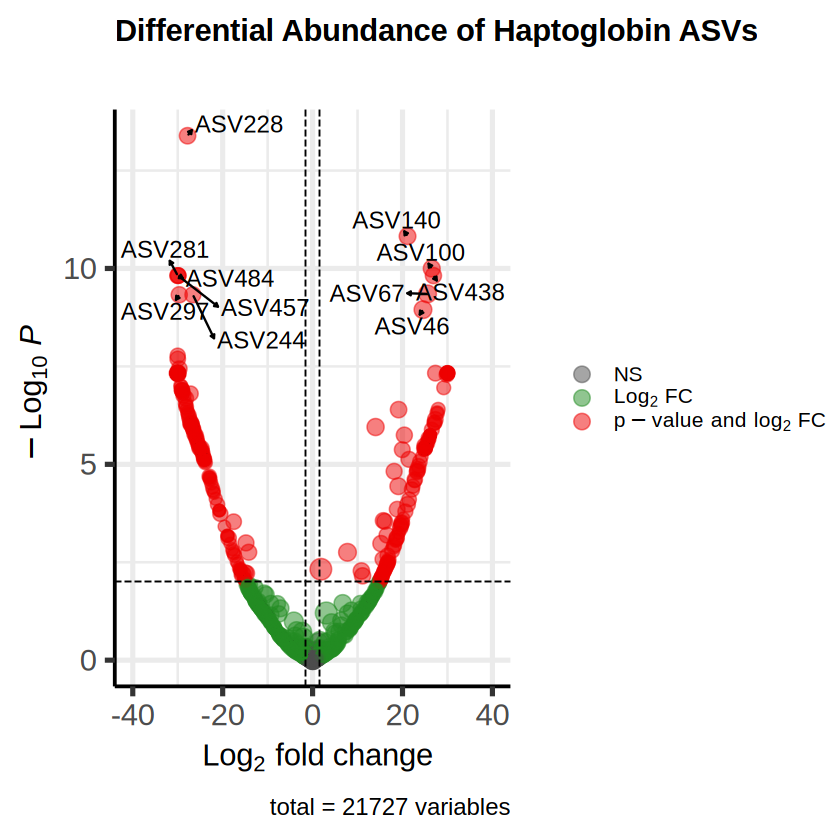

In [215]:
volcano_plot

In [216]:
ggsave(
  filename = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Figures/Volcano_Haptoglobin_ASVs.png",
  plot = volcano_plot,
  width = 10,
  height = 8,
  dpi = 300
)

Warning message:
“ggrepel: 419 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates



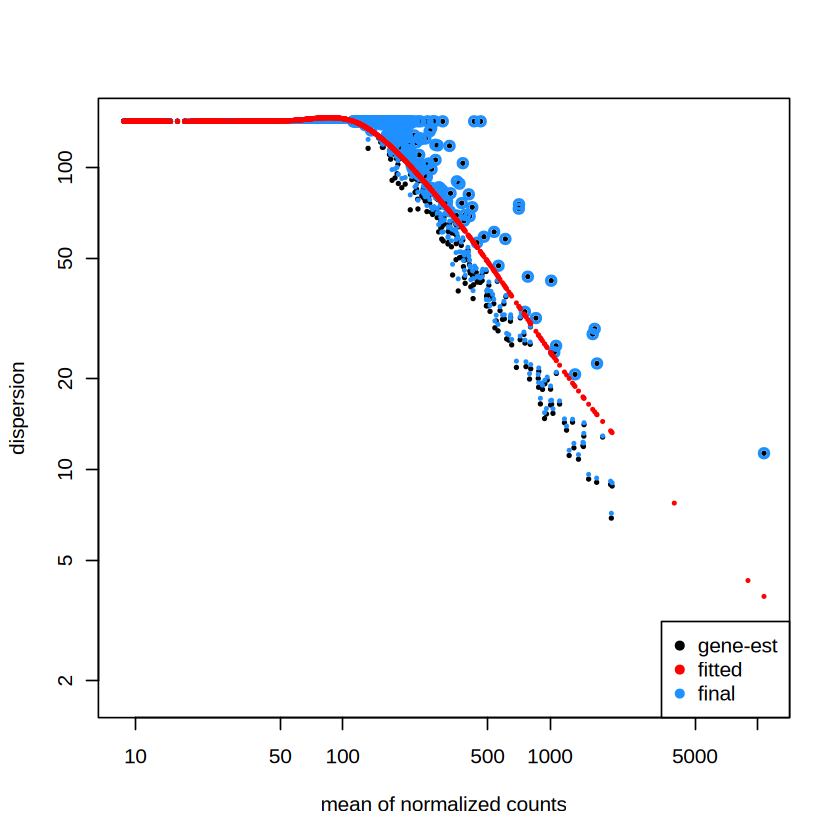

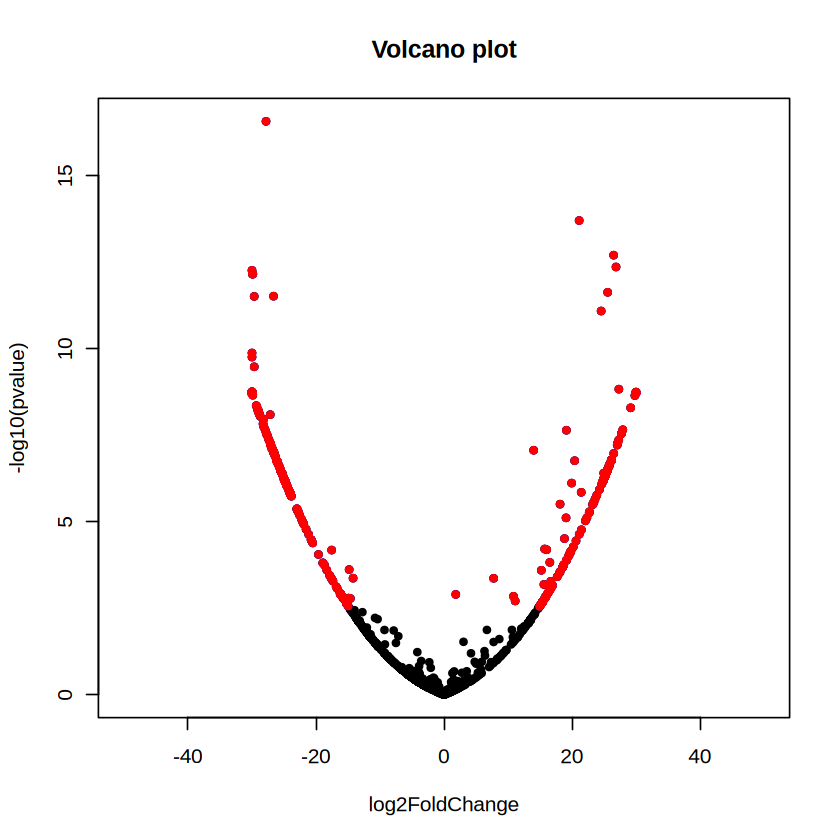

In [217]:
# Size factor estimation 
dds_Hapto <- estimateSizeFactors(dds_Hapto, type = "poscounts")

# Dispersion estimation
dds_Hapto <- estimateDispersions(dds_Hapto)

# Plot dispersion estimates
plotDispEsts(dds_Hapto)
par(mfrow=c(1,1))

# --- Volcano plots ---
# Basic volcano plot
with(result_Hapto, plot(log2FoldChange, -log10(pvalue),
                          pch=20, main="Volcano plot", xlim=c(-50,50)))
with(subset(result_Hapto, padj < 0.01),
     points(log2FoldChange, -log10(pvalue), pch=20, col="blue"))
with(subset(result_Hapto, padj < 0.01 & abs(log2FoldChange) > 1.5),
     points(log2FoldChange, -log10(pvalue), pch=20, col="red"))


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


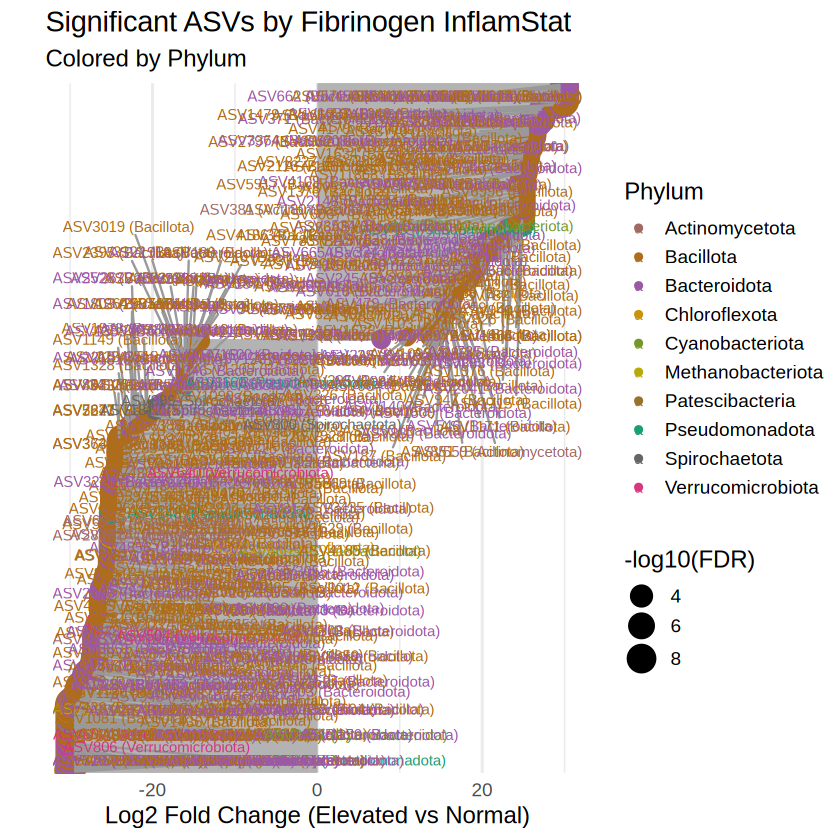

In [218]:
library(ggplot2)
library(dplyr)
library(ggrepel)

# Filter significant ASVs
lollipop_data <- result_Hapto_sorted %>%
  filter(padj < 0.01 & abs(log2FoldChange) > 2) %>%
  mutate(
    Tax_label = paste0(ASV, " (", Phylum, ")"),
    Signif_size = -log10(padj + 1e-10),
    Direction = ifelse(log2FoldChange > 0, 
                       "Enriched_in_Elevated", 
                       "Enriched_in_Normal")
  )

# Order factor by effect size
lollipop_data <- lollipop_data %>%
  arrange(log2FoldChange) %>%
  mutate(Tax_label = factor(Tax_label, levels = unique(Tax_label)))


phylum_list <- unique(lollipop_data$Phylum)
phylum_colors <- setNames(
  colorRampPalette(RColorBrewer::brewer.pal(8, "Dark2"))(length(phylum_list)),
  phylum_list
)

# Lollipop plot
ggplot(lollipop_data, aes(x = log2FoldChange, y = Tax_label)) +
  
  # sticks
  geom_segment(aes(x = 0, xend = log2FoldChange, 
                   y = Tax_label, yend = Tax_label),
               color = "gray70", size = 0.6) +
  
  # balls colored by phylum
  geom_point(aes(size = Signif_size, color = Phylum)) +
  
  # labels
  geom_text_repel(aes(label = Tax_label, color = Phylum),
                  size = 3, 
                  max.overlaps = Inf,
                  box.padding = 0.3,
                  point.padding = 0.3,
                  segment.color = "gray60") +
  
  scale_color_manual(values = phylum_colors) +
  scale_size_continuous(name = "-log10(FDR)", range = c(3, 8)) +
  
  labs(
    x = "Log2 Fold Change (Elevated vs Normal)",
    y = "",
    title = "Significant ASVs by Fibrinogen InflamStat",
    subtitle = "Colored by Phylum"
  ) +
  
  theme_minimal(base_size = 14) +
  theme(
    panel.grid.major.y = element_blank(),
    axis.text.y = element_blank(),
    legend.position = "right"
  )


In [91]:
# Co-relation analysis

In [219]:
vsd_hapto <- vst(dds_Hapto, blind = FALSE)
vsd_mat_hapto <- assay(vsd_hapto)
#Normalizing counts


-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.



In [220]:
# Differential abundant ASV
hapto_sig_asvs <- result_Hapto_sorted %>%
  filter(padj < 0.05 & abs(log2FoldChange) > 2) %>%
  pull(ASV)


In [221]:
hapto_vsd_sig <- vsd_mat_hapto[hapto_sig_asvs, , drop = FALSE]


In [222]:
meta <- as.data.frame(colData(dds_Hapto))

# Make sure samples align
all(colnames(hapto_vsd_sig) == rownames(meta))  # must be TRUE


[1] TRUE

In [223]:
is.numeric(meta$Haptoglobin_Mean)
is.numeric(hapto_vsd_sig[1, ])


[1] TRUE

[1] TRUE

In [224]:
hapto_cor_results <- lapply(rownames(hapto_vsd_sig), function(asv) {
  x <- hapto_vsd_sig[asv, ]
  y <- meta$Haptoglobin_Mean
  
  res <- cor.test(x, y, method = "spearman", exact = FALSE)
  
  data.frame(
    ASV = asv,
    Spearman_rho = res$estimate,
    p_value = res$p.value
  )
})

hapto_cor_results_df <- do.call(rbind, hapto_cor_results)


In [225]:
hapto_cor_results_full <- hapto_cor_results_df %>%
  left_join(result_Hapto_sorted, by = "ASV")


In [226]:
write.csv(
  hapto_cor_results_full,
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Hapto_ASV_Spearman_correlations.csv",
  row.names = FALSE
)


In [227]:
# Read the saved Spearman correlation results
hapto_cor_results_full <- read.csv(
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Hapto_ASV_Spearman_correlations.csv",
  header = TRUE,
  stringsAsFactors = FALSE
)

# Check the top rows
head(hapto_cor_results_full)


,ASV,Spearman_rho,p_value,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ASV36,0.007210954,0.93212620,716.7203,7.759406,2.204940,3.519101,4.330114e-04,1.764638e-03,AGAGACTGAACCAGCCAAGTCGCGTGAGGGAAGACTGCCCTATGGGTTGTAAACCTCTTTAGTCGGGGAGCAAAAAAGCGGACGTGTCCGCCATTGAGCGTACCCGAAGAATAAGCATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGTTTAATAAGTCAGCGGTTAAATGTCGGGGCTCAACCTCGGCCTGCCGTTGAAACTGTTGAACTAGAGTTAGAGTGGAGCATGCGGAATGCGCAGTGTAGCGGTGAAATGCATAGATATTGCGCAGAACTCCGATCGCGAAGGCAGCGTGCTAACTCTCGACTGACGCTGAGGCACGAAAG,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Muribaculaceae,NA,NA
2,ASV67,-0.052688510,0.53345578,707.3904,25.576852,3.647671,7.011831,2.352190e-12,4.457400e-10,AAACCCTGACGCAGCAATGCCGCGTGAAGGATGAAGGTTTTCGGATTGTAAACTTCTTTTGTTAAGGACGAAATTTGACGGTACTTAACGAATAAGCTCCGGCTAACTATGTGCCAGCAGCCGCGGTAATACATAGGGAGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGTGCGTAGGCGGCTAAGCAAGTCAGATGTGAAATCTATGGGCTCAACCCATAGTCTGCATTTGAAACTGTTTAGCTTGAGTGAGGTAGAGGCAGGCGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGGCCTGCTGGGCCTTAACTGACGCTGAGGCACGAAAG,Bacteria,Bacillota,Clostridia,Oscillospirales,Ruminococcaceae,NA,NA
3,ASV46,-0.148570521,0.07763428,705.9065,24.553317,3.592057,6.835447,8.174952e-12,1.126657e-09,AAACTCTGATGCAGCCATGCCGCGTGTGTGAAGAAGGCCTTCGGGTTGTAAAGCACTTTCGGAGGGGAGGAAAAGATGACGTTACCCTCAGAAGAAGCACCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGGTGCAAGCGTTAATCGGAATAACTGGGCGTAAAGGGCATGCAGGCGGTTATACAAGTAGGATGTGAAAGCCTGGGGCTCAACCTCAGAACTGCATTCTAAACTGTGTGACTAGAGTATTGCAGGGGGAGACGGAATTTCAGGTGTAGCGGTGGAATGCGTAGATATCTGAAAGAACACCAAAGGCGAAGGCAGTCTCCTGGGCAAATACTGACGCTCATATGCGAAAG,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Succinivibrionaceae,Succinivibrio,NA
4,ASV105,-0.144653364,0.08587805,555.8485,6.703752,2.712669,2.471276,1.346320e-02,3.531180e-02,CAAGTCTGAACCAGCCATGCCGCGTGCAGGATGACGGCTCTATGAGTTGTAAACTGCTTTTGTATGAGGGTAAAATTGGGTACGTGTACCCAACTGCAAGTATCATACGAATAAGGATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGATCCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGTTTGGTAAGTTAGAGGTGAAATTTCAGGGCTCAACCTTGACATTGCCTCTGATACTGCCGAGCTAGAGAGTAGTTGCTGTGGGCGGAATGTATGGTGTAGCGGTGAAATGCTTAGAGATCATACAGAACACCGATTGCGAAGGCAGCTCACAAAACTATATCTGACGTTGAGGCACGAAAG,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes,NA
5,ASV92,-0.131987487,0.11740270,493.7146,14.009429,2.616856,5.353535,8.625245e-08,1.117596e-06,AAACCCTGATGCAGCAACGCCGCGTGAGTGATGACGGCCTTCGGGTTGTAAAGCTCTGTCTTCAGGGACGATAATGACGGTACCTGAGGAGGAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGCGTAAAGGGAGCGTAGGCGGACTTTTAAGTGAGATGTGAAATACCCGGGCTCAACTTGGGTGCTGCATTTCAAACTGGAAGTCTAGAGTGCAGGAGAGGAGAATGGAATTCCTAGTGTAGCGGTGAAATGCGTAGAGATTAGGAAGAACACCAGTGGCGAAGGCGATTCTCTGGACTGTAACTGACGCTGAGGCTCGAAAG,Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium,NA
6,ASV90,-0.071087054,0.40052891,461.9885,-15.534303,4.981010,-3.118705,1.816476e-03,6.541039e-03,AGAGCCTGAACCAGCCAAGTAGCGTGAAGGATGACTGCCCTATGGGTTGTAAACTTCTTTTGTTTGGGAATAAAGTGAGGTACGTGTACCTTTTTGTATGTACCATTCGAATAAGCATCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTGTTAAGTCAGCGGTTAAATTTCCAGGCCCAACCTGGTCTTGCCGTTGAAACTGGCGGTCTTGAATGCACACAAGGGAGATGGAATTCGTCGTGTAGCGGTGAAATGCTTAGATATGACGAAGAACTCCGATTGCGAAGGCAGTCTCCTGGGGTGCTATTGACGCTGAGGCTCGAAAG,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Prevotellaceae UCG-003,NA


In [229]:
# Ensure base data.frame
hapto_cor_df <- as.data.frame(hapto_cor_results_full)

# Make sure numeric columns are numeric
hapto_cor_df$Spearman_rho <- as.numeric(hapto_cor_df$Spearman_rho)
hapto_cor_df$p_value     <- as.numeric(hapto_cor_df$p_value)

# Select only needed columns
hapto_cor_df_small <- hapto_cor_df[, c("ASV", "Spearman_rho", "p_value")]

# Top 20 by absolute rho
top_hits <- hapto_cor_df_small[order(-abs(hapto_cor_df_small$Spearman_rho)), ][1:20, ]

top_hits


,ASV,Spearman_rho,p_value
,<chr>,<dbl>,<dbl>
116,ASV665,-0.2357131,0.004743978
9,ASV96,0.2309625,0.005685275
261,ASV1363,-0.2289217,0.006138438
53,ASV304,-0.2205916,0.008339736
254,ASV1918,0.2171751,0.009428095
614,ASV940,-0.2144295,0.010391680
123,ASV632,-0.2071856,0.013361521
313,ASV3076,-0.1924549,0.021756732
106,ASV491,0.1921620,0.021961710


In [231]:
asvs_to_plot <- top_hits$ASV
asvs_to_plot

[1] "ASV665"  "ASV96"   "ASV1363" "ASV304"  "ASV1918" "ASV940"  "ASV632" 
 [8] "ASV3076" "ASV491"  "ASV228"  "ASV229"  "ASV1713" "ASV999"  "ASV100" 
[15] "ASV1131" "ASV469"  "ASV659"  "ASV1909" "ASV4868" "ASV1093"

In [232]:
# Extract sample data as a dataframe and clean qPCR
meta <- as.data.frame(sample_data(ps))

meta$qpcr_16s_copies_ul <- gsub(",", "", meta$qpcr_16s_copies_ul)
meta$qpcr_16s_copies_ul[meta$qpcr_16s_copies_ul %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
meta$qpcr_16s_copies_ul <- as.numeric(meta$qpcr_16s_copies_ul)


# Replace sample_data in ps
sample_data(ps) <- sample_data(meta)

#Extract OTU/ASV table and normalize to relative abundance
norm_mat <- as(otu_table(ps), "matrix")
if(!taxa_are_rows(ps)) norm_mat <- t(norm_mat)
norm_mat <- sweep(norm_mat, 2, colSums(norm_mat), "/")

# Calculate absolute abundance using qPCR
abs_abundance <- sweep(norm_mat, 2, meta$qpcr_16s_copies_ul, FUN = "*")

# Log-transform for plotting
abs_abundance_log <- log10(abs_abundance + 1)




In [234]:
norm_mat <- as(otu_table(ps), "matrix")
if(!taxa_are_rows(ps)) norm_mat <- t(norm_mat)
norm_mat <- sweep(norm_mat, 2, colSums(norm_mat), "/")

meta <- data.frame(sample_data(ps))
meta$Haptoglobin_Mean <- as.numeric(meta$Haptoglobin_Mean)


In [235]:
tax <- as.data.frame(tax_table(ps))


In [236]:
get_tax_label <- function(asv) {
  g <- tax[asv, "Genus"]
  c <- tax[asv, "Class"]

  if (!is.na(g) && g != "") {
    return(g)
  } else if (!is.na(c) && c != "") {
    return(paste0("Class: ", c))
  } else {
    return("Taxon: Unknown")
  }
}


In [240]:
library(ggplot2)
library(patchwork)

plot_list <- list()

for(asv in asvs_to_plot){

  df_plot <- data.frame(
    Abundance = as.numeric(abs_abundance_log[asv, ]),
    Haptoglobin = meta$Haptoglobin_Mean
  )

  # correlation values
  rho  <- top_hits$Spearman_rho[top_hits$ASV == asv]
  pval <- top_hits$p_value[top_hits$ASV == asv]

  # Get taxon name 
  tax_label <- get_tax_label(asv)


  plot_title <- paste0(asv, " (", tax_label, ")")

  p <- ggplot(df_plot, aes(x = Haptoglobin, y = Abundance)) +
    geom_point(size = 2, alpha = 0.7) +
    geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
    labs(
      title = plot_title,
      subtitle = paste0("Spearman rho = ", round(rho, 3),
                        " | p = ", signif(pval, 3)),
      x = "Haptoglobin Mean",
      y = "Log10 Absolute Abundance"
    ) +
    theme_minimal(base_size = 12)

  plot_list[[asv]] <- p
}


`geom_smooth()` using formula = 'y ~ x'


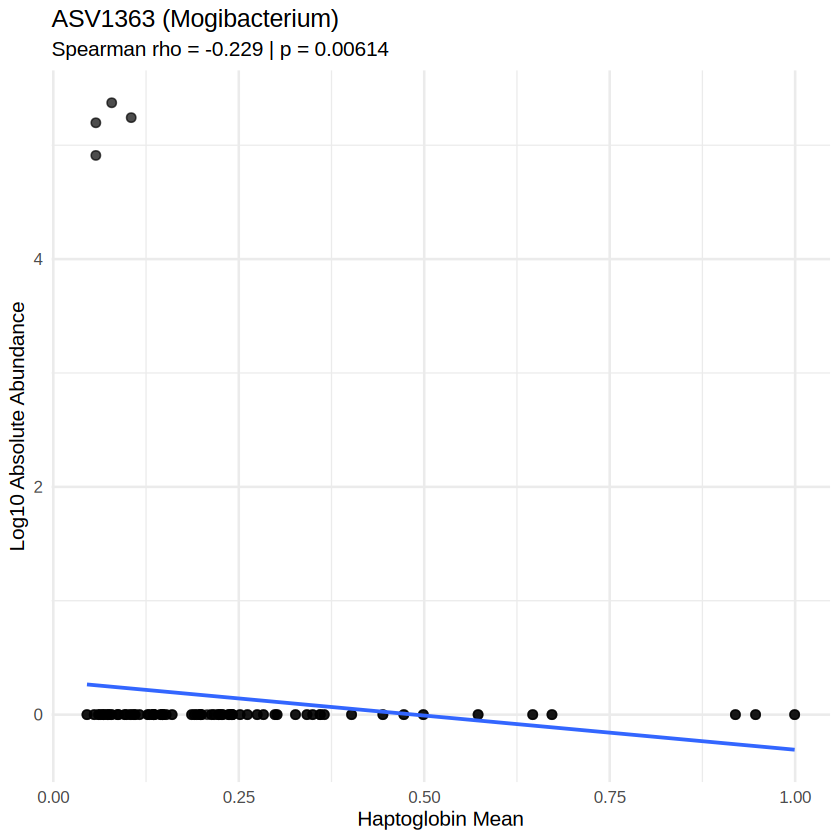

In [241]:
# Show the first ASV plot
print(plot_list[[3]])


In [242]:
pdf("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/ASV_Haptoglobin_Scatter_Plots.pdf",
    width = 7, height = 6)

for(p in plot_list){
  print(p)
}

dev.off()


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [243]:
library(patchwork)

combined_plot <- wrap_plots(plot_list, ncol = 3)


In [244]:
ggsave(
  "/scratch/negishi/ldas/COW_INFLAMMATION/Figures/ASV_Haptoglobin_Scatter_Grid.svg",
  combined_plot,
  width = 14,
  height = 12
)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [67]:
# At genus level

In [ ]:

# ---------------------------
# Load phyloseq and collapse to Genus
# ---------------------------


ps.genus <- tax_glom(ps, taxrank = "Genus")
taxa_names(ps.genus) <- make.unique(as.character(tax_table(ps.genus)[, "Genus"]))

# Extract OTU/genus table
otu <- as(otu_table(ps.genus), "matrix")

if (!all(otu == round(otu))) {
  message("Rounding counts to integers")
  otu <- round(otu)
}

# Make sure orientation is taxa (rows) x samples (columns)
if (!taxa_are_rows(ps.genus)) {
  otu <- t(otu)
}

In [ ]:
# ---------------------------
# Metadata preparation
# ---------------------------
meta_genus <- data.frame(sample_data(ps.genus))

# Extraction date as categorical batch
meta_genus$ExtractionDate <- as.Date(meta_genus$ExtractionDate, format = "%m/%d/%Y")
meta_genus$ExtractionDate_cat <- factor(meta_genus$ExtractionDate)

# Parity group
meta_genus$Parity_numeric <- as.numeric(as.character(meta_genus$Parity))
meta_genus$Parity_Group <- factor(ifelse(meta_genus$Parity_numeric <= 3, "Group1", "Group2"))

# BCS group
meta_genus$BCS <- as.numeric(as.character(meta_genus$BCS))
meta_genus$BCS_Group <- factor(cut(meta_genus$BCS,
                             breaks = c(-Inf, 2.5, 3.5, Inf),
                             labels = c("Low", "Medium", "High"),
                             right = TRUE))

# Inflammation status
meta_genus$Haptoglobin_InflamStat <- factor(meta_genus$Haptoglobin_InflamStat,
                                      levels = c("Normal", "Elevated"))
meta_genus$Haptoglobin_InflamStat <- relevel(meta_genus$Haptoglobin_InflamStat, ref = "Normal")
library(phyloseq)



# Create Haptoglobin_Mean column
if (all(c("Haptoglobin_1DIM", "Haptoglobin_3DIM") %in% colnames(meta_genus))) {
  meta_genus$Haptoglobin_Mean <- rowMeans(meta_genus[, c("Haptoglobin_1DIM", "Haptoglobin_3DIM")], na.rm = TRUE)
} else if ("Haptoglobin_1DIM" %in% colnames(meta_genus)) {
  meta_genus$Haptoglobin_Mean <- meta_genus$Haptoglobin_1DIM
} else {
  stop("No Haptoglobin columns found in metadata")
}

meta_genus$Haptoglobin_Mean <- as.numeric(meta_genus$Haptoglobin_Mean)

# Replace sample_data in phyloseq object
sample_data(ps.genus) <- sample_data(meta_genus)

# Now ps.genus permanently has Haptoglobin_Mean in its sample_data
head(sample_data(ps.genus))


In [145]:

# ---------------------------
# Create DESeq2 dataset
# ---------------------------
dds_Hapto_genus <- DESeqDataSetFromMatrix(
  countData = otu,
  colData   = meta_genus,
  design    = ~ Haptoglobin_InflamStat + BCS_Group + Parity_Group + ExtractionDate_cat
)

# Size factor estimation (poscounts is safer for sparse microbiome data)
dds_Hapto_genus <- estimateSizeFactors(dds_Hapto_genus, type = "poscounts")

# Run DESeq2
dds_Hapto_genus <- DESeq(dds_Hapto_genus)

# ---------------------------
# Extract results
# ---------------------------
alpha <- 0.01

result_Hapto_genus <- results(dds_Hapto_genus,
                        contrast = c("Haptoglobin_InflamStat", "Elevated", "Normal"),
                        alpha = alpha)

# Order by adjusted p-value
result_Hapto_genus <- result_Hapto_genus[order(result_Hapto_genus$padj, na.last = NA), ]

# Add Genus names
result_Hapto_genus$Genus <- rownames(result_Hapto_genus)

# Save
write.csv(as.data.frame(result_Hapto_genus),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/DESeq2_genus_Haptoglobin.csv",
          row.names = FALSE)


converting counts to integer mode

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column nam

In [146]:
tax <- as.data.frame(tax_table(ps))
sum(is.na(tax$Genus))         # number of ASVs with no Genus
table(is.na(tax$Genus))


[1] 7341


FALSE  TRUE 
14386  7341 

In [147]:
dim(otu)
head(rownames(otu))
head(tax_table(ps.genus)[, "Genus"])


[1] 971 142

[1] "Bifidobacterium"             "Paeniclostridium"           
[3] "Rikenellaceae RC9 gut group" "Turicibacter"               
[5] "Romboutsia"                  "Prevotellaceae UCG-003"

,Genus
Bifidobacterium,Bifidobacterium
Paeniclostridium,Paeniclostridium
Rikenellaceae RC9 gut group,Rikenellaceae RC9 gut group
Turicibacter,Turicibacter
Romboutsia,Romboutsia
Prevotellaceae UCG-003,Prevotellaceae UCG-003


In [148]:
summary(result_Hapto_genus)


out of 129 with nonzero total read count
adjusted p-value < 0.01
LFC > 0 (up)       : 20, 16%
LFC < 0 (down)     : 9, 7%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [149]:
sig <- result_Hapto_genus[which(result_Hapto_genus$padj < 0.01), ]
# Upregulated in Elevated (log2FC > 0)
sig_up <- sig[sig$log2FoldChange > 0, ]

# Downregulated in Elevated (so enriched in Normal; log2FC < 0)
sig_down <- sig[sig$log2FoldChange < 0, ]


In [150]:
# Top 10 up
head(sig_up[order(sig_up$padj), ], 20)

# Top 10 down
head(sig_down[order(sig_down$padj), ], 20)


log2 fold change (MLE): Haptoglobin_InflamStat Elevated vs Normal 
Wald test p-value: Haptoglobin InflamStat Elevated vs Normal 
DataFrame with 20 rows and 7 columns
                                  baseMean log2FoldChange     lfcSE      stat
                                 <numeric>      <numeric> <numeric> <numeric>
[Eubacterium] xylanophilum group  19.06921        28.5997   3.84258   7.44284
Elusimicrobium                    16.56960        27.8806   3.84156   7.25764
Anaerobiospirillum                16.34703        27.8890   3.84227   7.25847
Arcanobacterium                   10.10104        27.4265   3.84259   7.13750
Papillibacter                      5.45503        27.1327   3.84281   7.06064
...                                    ...            ...       ...       ...
Zag_111                           334.8777        9.24657   2.47220   3.74022
Peribacillus                       16.9339       13.66850   3.84273   3.55698
Hydrogenoanaerobacterium           85.0062       13.28

log2 fold change (MLE): Haptoglobin_InflamStat Elevated vs Normal 
Wald test p-value: Haptoglobin InflamStat Elevated vs Normal 
DataFrame with 9 rows and 7 columns
                   baseMean log2FoldChange     lfcSE      stat      pvalue
                  <numeric>      <numeric> <numeric> <numeric>   <numeric>
Salmonella        110.51212      -29.97031   3.84151  -7.80169 6.10817e-15
Gordonibacter      53.90951      -25.01957   3.84335  -6.50983 7.52376e-11
Raoultibacter       9.89014      -24.82632   3.84402  -6.45843 1.05795e-10
Selenomonas        12.68138      -24.83448   3.84402  -6.46055 1.04320e-10
Aeriscardovia       1.31763      -20.53254   3.84389  -5.34160 9.21300e-08
Anaerosporobacter   1.31763      -20.53254   3.84389  -5.34160 9.21300e-08
Nocardioides        1.31763      -20.53254   3.84389  -5.34160 9.21295e-08
Lachnoclostridium 328.54783       -9.25276   2.76860  -3.34203 8.31668e-04
Extibacter        157.59158      -10.87069   3.38876  -3.20787 1.33722e-03
          

In [151]:
write.csv(as.data.frame(sig_up),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/DESeq2_genus_Haptoglobin_up.csv",
          row.names = FALSE)

write.csv(as.data.frame(sig_down),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/DESeq2_genus_Haptoglobin_down.csv",
          row.names = FALSE)


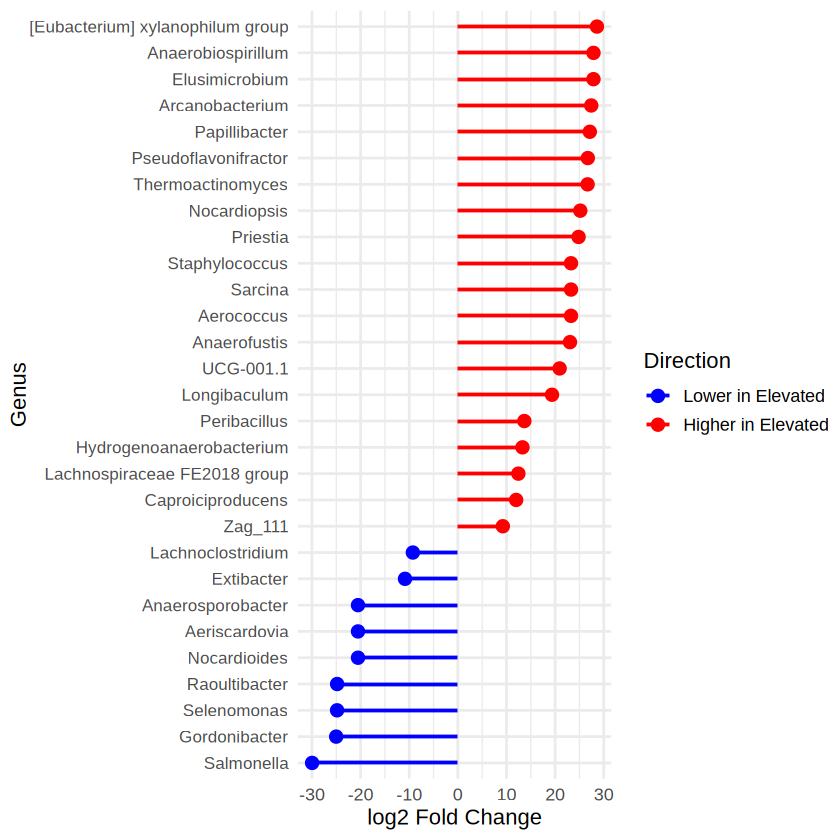

In [152]:
library(dplyr)
library(ggplot2)

# Convert to data frame and keep significant genera
sig_df <- as.data.frame(result_Hapto_genus)
sig_df$Genus <- rownames(sig_df)

sig_df <- sig_df %>%
  filter(!is.na(padj) & padj < 0.01)

# Order genera on y-axis by fold change
sig_df$Genus <- factor(sig_df$Genus,
                       levels = sig_df$Genus[order(sig_df$log2FoldChange)])

# Plot
p <- ggplot(sig_df, aes(x = Genus, y = log2FoldChange,
                        color = log2FoldChange > 0)) +
  geom_segment(aes(xend = Genus, y = 0, yend = log2FoldChange),
               linewidth = 0.8) +
  geom_point(size = 3) +
  coord_flip() +
  scale_color_manual(
    values = c("TRUE"="red", "FALSE"="blue"),
    labels = c("TRUE"="Higher in Elevated", "FALSE"="Lower in Elevated")
  ) +
  labs(
    
    x = "Genus",
    y = "log2 Fold Change",
    color = "Direction"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "right",
    axis.text.y = element_text(size = 10)
  )

p


In [153]:
res_df <- as.data.frame(result_Hapto_genus)
res_df$Genus <- rownames(res_df)

# Remove rows with NA padj (DESeq2 filtering)
res_df <- res_df %>% filter(!is.na(padj))

p_volcano <- ggplot(res_df,
                    aes(x = log2FoldChange,
                        y = -log10(padj))) +
  geom_point(aes(color = padj < 0.01),
             alpha = 0.7,
             size = 2.8) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray40") +
  scale_color_manual(
    values = c("FALSE" = "gray70", "TRUE" = "red"),
    labels = c("FALSE" = "Not significant", "TRUE" = "padj < 0.01"),
    
  ) +
  labs(
    x = "log2 Fold Change (Elevated vs Normal)",
    y = "-log10 Adjusted p-value",
    
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "top",
    plot.title = element_text(size = 14, face = "bold")
  )

# Save
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/DESeq2_genus_Haptoglobin_volcano.png",
       plot = p_volcano, width = 7, height = 6, dpi = 300)


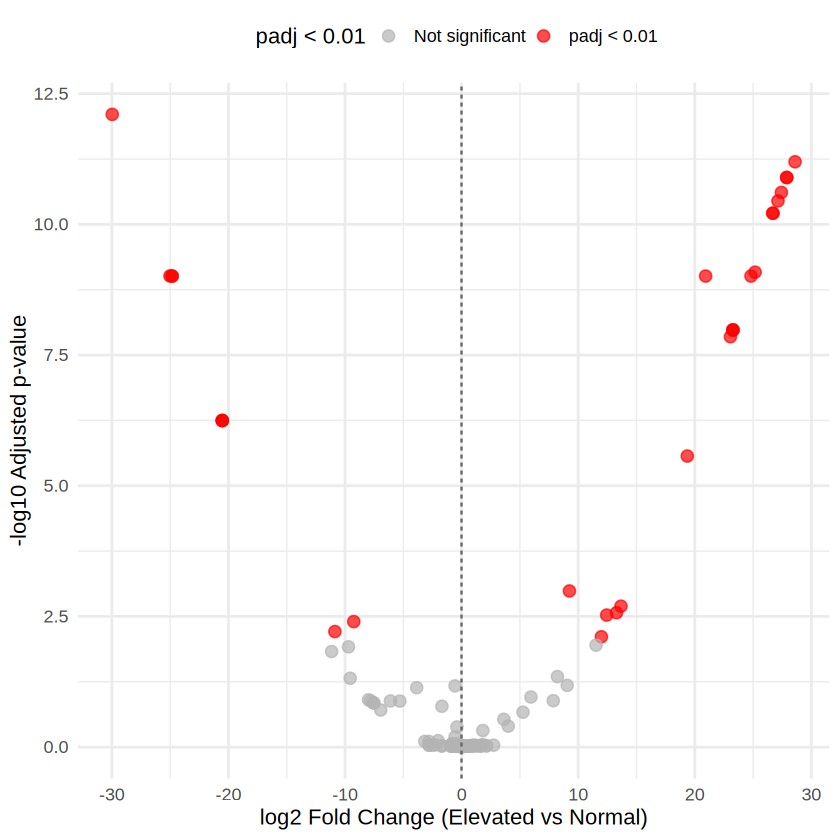

In [154]:
p_volcano

In [ ]:
# Corellation

In [156]:
# Differentail abundant genera_Haptoglobin
sig

log2 fold change (MLE): Haptoglobin_InflamStat Elevated vs Normal 
Wald test p-value: Haptoglobin InflamStat Elevated vs Normal 
DataFrame with 29 rows and 7 columns
                                  baseMean log2FoldChange     lfcSE      stat
                                 <numeric>      <numeric> <numeric> <numeric>
Salmonella                        110.5121       -29.9703   3.84151  -7.80169
[Eubacterium] xylanophilum group   19.0692        28.5997   3.84258   7.44284
Elusimicrobium                     16.5696        27.8806   3.84156   7.25764
Anaerobiospirillum                 16.3470        27.8890   3.84227   7.25847
Arcanobacterium                    10.1010        27.4265   3.84259   7.13750
...                                    ...            ...       ...       ...
Hydrogenoanaerobacterium           85.0062       13.28685   3.82941   3.46969
Lachnospiraceae FE2018 group      102.5644       12.44039   3.62545   3.43141
Lachnoclostridium                 328.5478       -9.25

In [157]:
vsd_hapto_genus <- varianceStabilizingTransformation(dds_Hapto_genus, blind = FALSE)
vsd_mat_hapto_genus <- assay(vsd_hapto_genus)

#Normalizing counts


In [158]:
sig_df <- as.data.frame(result_Hapto_genus)
sig_df$Genus <- rownames(sig_df)
sig_genera <- sig_df %>% filter(!is.na(padj) & padj < 0.01) %>% pull(Genus)


In [159]:

vsd_sig <- vsd_mat_hapto_genus[sig_genera, ]



In [174]:
meta_genus <- as.data.frame(colData(dds_Hapto_genus))

# Make sure samples align
all(colnames(vsd_sig) == rownames(meta_genus))  # must be TRUE


[1] TRUE

In [175]:
colnames(meta_genus)


[1] "X"                                        
 [2] "Sample_ID"                                
 [3] "Corrected_Sample_ID"                      
 [4] "Cow_ID"                                   
 [5] "DIM_Collected"                            
 [6] "Date_Collected"                           
 [7] "Date_Recieved"                            
 [8] "Farm"                                     
 [9] "Sample_Type"                              
[10] "Sex"                                      
[11] "BCS"                                      
[12] "Parity"                                   
[13] "Housing_type"                             
[14] "Fibrinogen_1DIM"                          
[15] "Fibrinogen_3DIM"                          
[16] "Fibrinogen_7DIM"                          
[17] "Fibrinogen_InflamStat"                    
[18] "FIBRINOGEN_MEAN"                          
[19] "MeanFibrinogen_InflamStat"                
[20] "Haptoglobin_1DIM"                         
[21] "Haptoglobin_3DIM"                         
[22] "Haptoglobin_InflamStat"                   
[23] "ExtractionDate"                           
[24] "ExtractionKit"                            
[25] "DNAElutionVolume"                         
[26] "DNAYield_ng"                              
[27] "qpcr_16s_copies_ul"                       
[28] "LinkerPrimerSequence"                     
[29] "ReverseSequence"                          
[30] "general.rawsamplename"                    
[31] "general.readlength"                       
[32] "general.readlengthr2"                     
[33] "general.runname"                          
[34] "general.samplename"                       
[35] "subsample.rawreads"                       
[36] "subsample.subsampledreads"                
[37] "fastqc.meanreadqualityR1"                 
[38] "fastqc.meanreadqualityR2"                 
[39] "fastqc.meanreadqualityR2.1"               
[40] "fastqc.pct.deduplicated"                  
[41] "fastqc.pct.dimer"                         
[42] "fastqc.pct.gc"                            
[43] "fastqc.sequencelength"                    
[44] "fastqc.totalsequences"                    
[45] "dedupmetric.PCRduplication"               
[46] "dedupmetric.Tileduplication"              
[47] "fastqspeciesscreen.pct.Adapters"          
[48] "fastqspeciesscreen.pct.Chloroplast"       
[49] "fastqspeciesscreen.pct.ITS"               
[50] "fastqspeciesscreen.pct.Mitochondria"      
[51] "fastqspeciesscreen.pct.PhiX"              
[52] "fastqspeciesscreen.pct.Synthetic_16S_mock"
[53] "fastqspeciesscreen.pct.Synthetic_ITS_mock"
[54] "fastqspeciesscreen.pct.Unaligned"         
[55] "fastqspeciesscreen.pct.Vectors"           
[56] "fastqspeciesscreen.pct.ecoli"             
[57] "fastqspeciesscreen.pct.human"             
[58] "fastqspeciesscreen.pct.mouse"             
[59] "fastqspeciesscreen.pct.rRNA"              
[60] "input"                                    
[61] "filtered"                                 
[62] "denoisedF"                                
[63] "denoisedR"                                
[64] "merged"                                   
[65] "nonchim"                                  
[66] "Sample_Type2"                             
[67] "is.neg"                                   
[68] "ExtractionDate_cat"                       
[69] "Parity_numeric"                           
[70] "Parity_Group"                             
[71] "BCS_Group"                                
[72] "Haptoglobin_Mean"                         
[73] "sizeFactor"                               
[74] "replaceable"

In [176]:
var(meta_genus$Haptoglobin_Mean, na.rm = TRUE)


[1] 0.04126248

In [177]:
meta_genus <- as.data.frame(colData(dds_Hapto_genus))
meta_genus$Haptoglobin_Mean <- as.numeric(meta_genus$Haptoglobin_Mean)


In [178]:
# Keep genera present in at least 5 samples
keep_genera <- rownames(vsd_sig)[apply(vsd_sig, 1, function(x) sum(x != 0) >= 5)]
vsd_sig_filtered <- vsd_sig[keep_genera, ]

# Spearman correlations
hapto_genus_cor_results <- lapply(rownames(vsd_sig_filtered), function(genus) {
  x <- vsd_sig_filtered[genus, ]
  y <- meta_genus$Haptoglobin_Mean
  valid <- is.finite(x) & is.finite(y)
  x <- x[valid]; y <- y[valid]
  if(length(x) < 3 || sd(x) == 0 || sd(y) == 0) {
    return(data.frame(Genus=genus, Spearman_rho=NA, p_value=NA))
  }
  res <- cor.test(x, y, method="spearman", exact=FALSE)
  data.frame(Genus=genus, Spearman_rho=res$estimate, p_value=res$p.value)
})

hapto_genus_cor_results_df <- do.call(rbind, hapto_genus_cor_results)


In [179]:
hapto_genus_cor_results_df 

,Genus,Spearman_rho,p_value
,<chr>,<dbl>,<dbl>
rho,Salmonella,-0.12654645,0.1334367077
rho1,[Eubacterium] xylanophilum group,0.10684118,0.2056805690
rho2,Elusimicrobium,0.12326963,0.1438716859
rho3,Anaerobiospirillum,0.13971539,0.0972509367
rho4,Arcanobacterium,0.10684118,0.2056805690
rho5,Papillibacter,0.12126998,0.1505369754
rho6,Thermoactinomyces,0.09245872,0.2737880797
rho7,Pseudoflavonifractor,0.13149684,0.1187841481
rho8,Nocardiopsis,0.09714124,0.2501182039


[1] TRUE

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


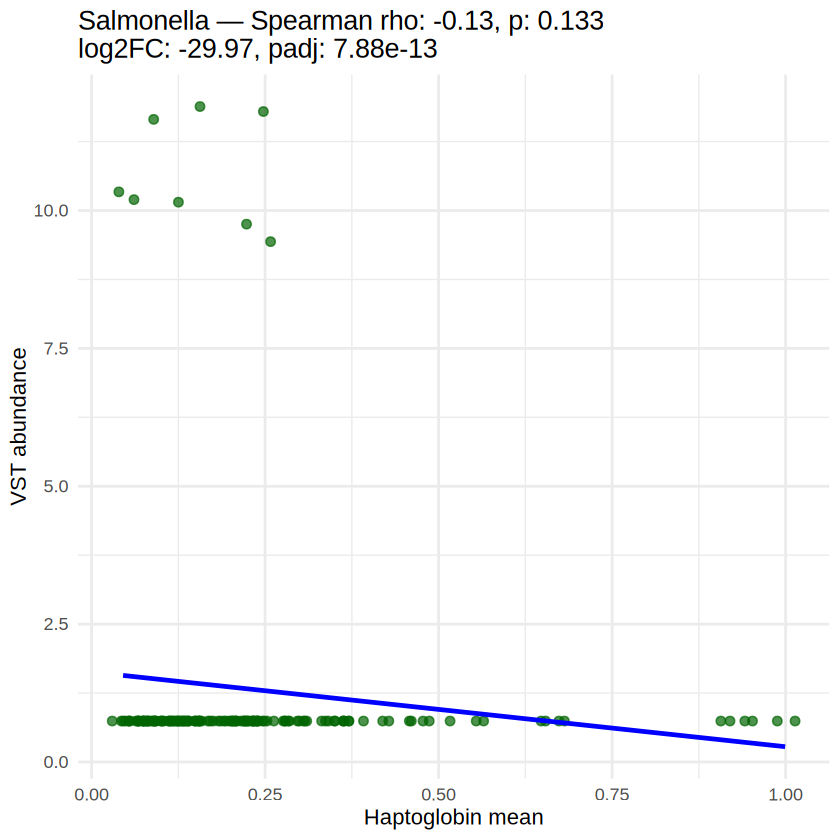

`geom_smooth()` using formula = 'y ~ x'


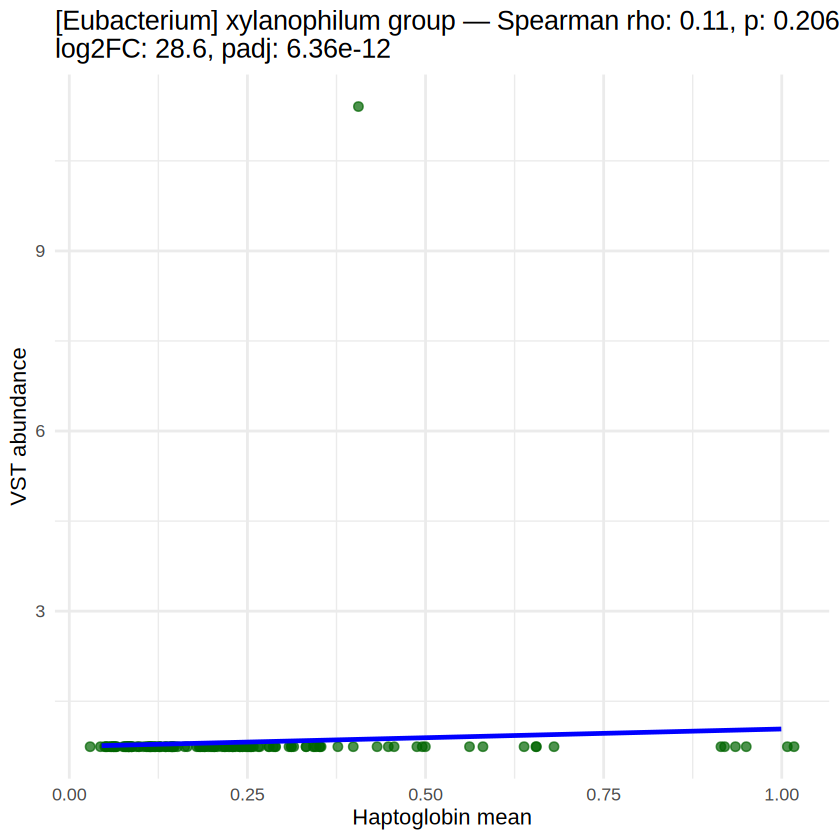

`geom_smooth()` using formula = 'y ~ x'


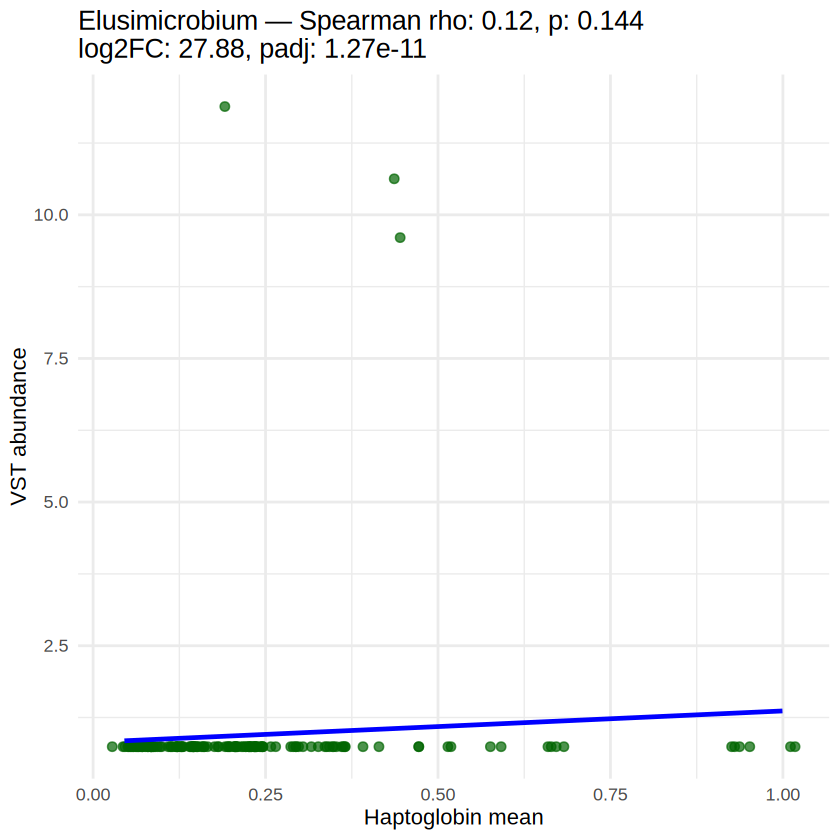

`geom_smooth()` using formula = 'y ~ x'


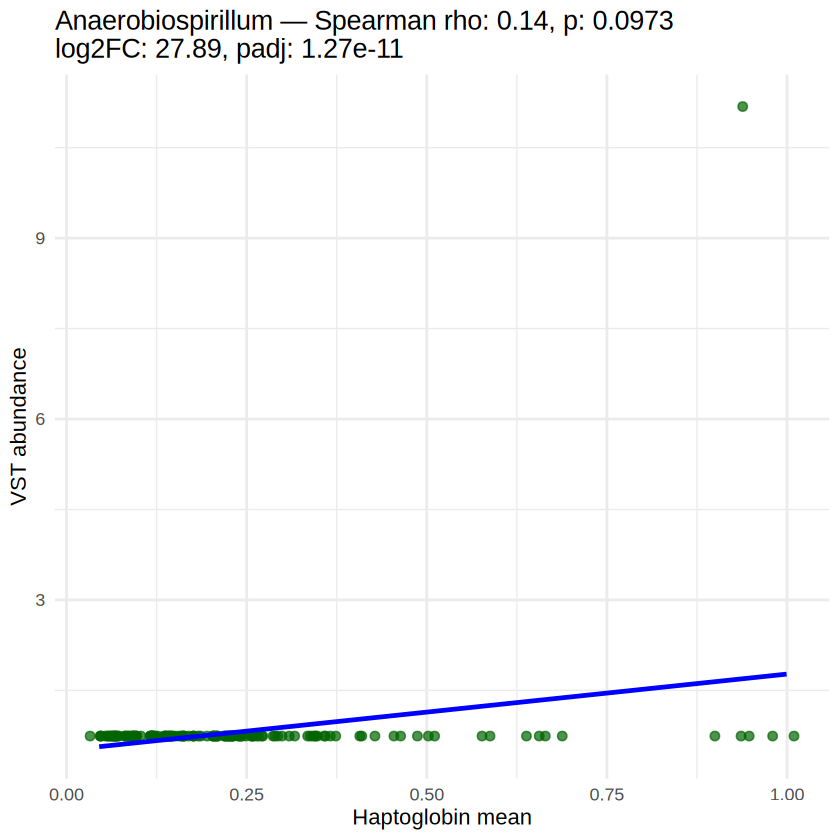

`geom_smooth()` using formula = 'y ~ x'


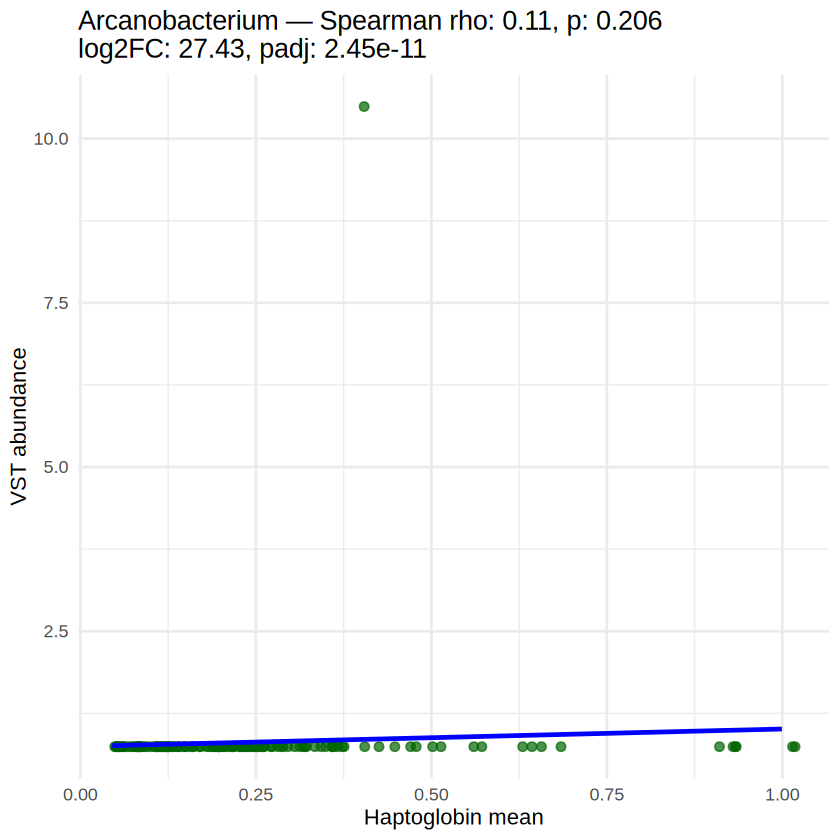

`geom_smooth()` using formula = 'y ~ x'


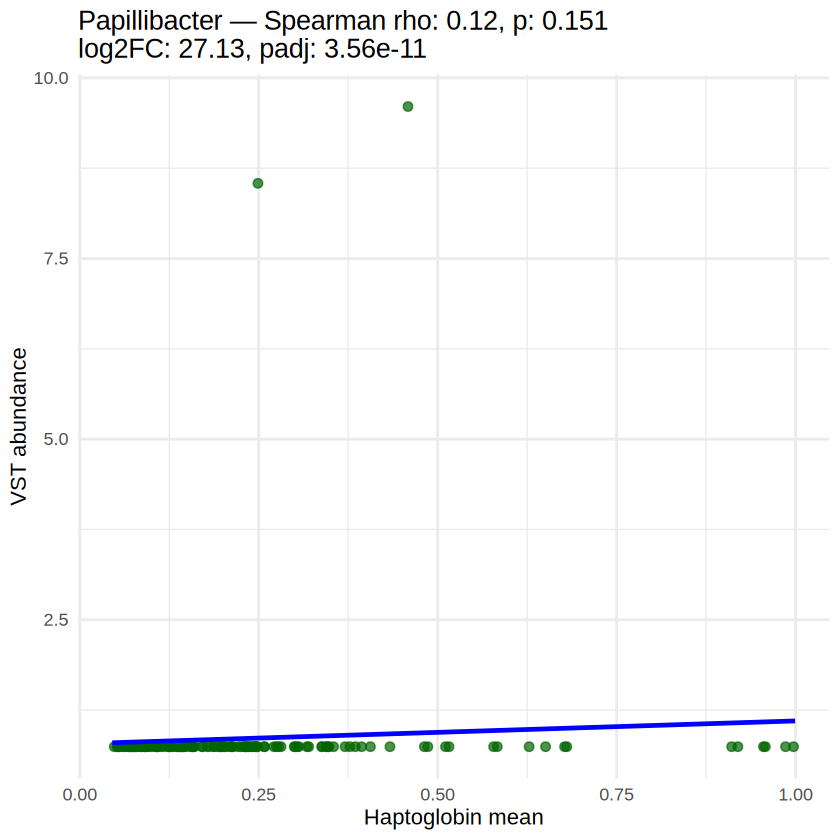

`geom_smooth()` using formula = 'y ~ x'


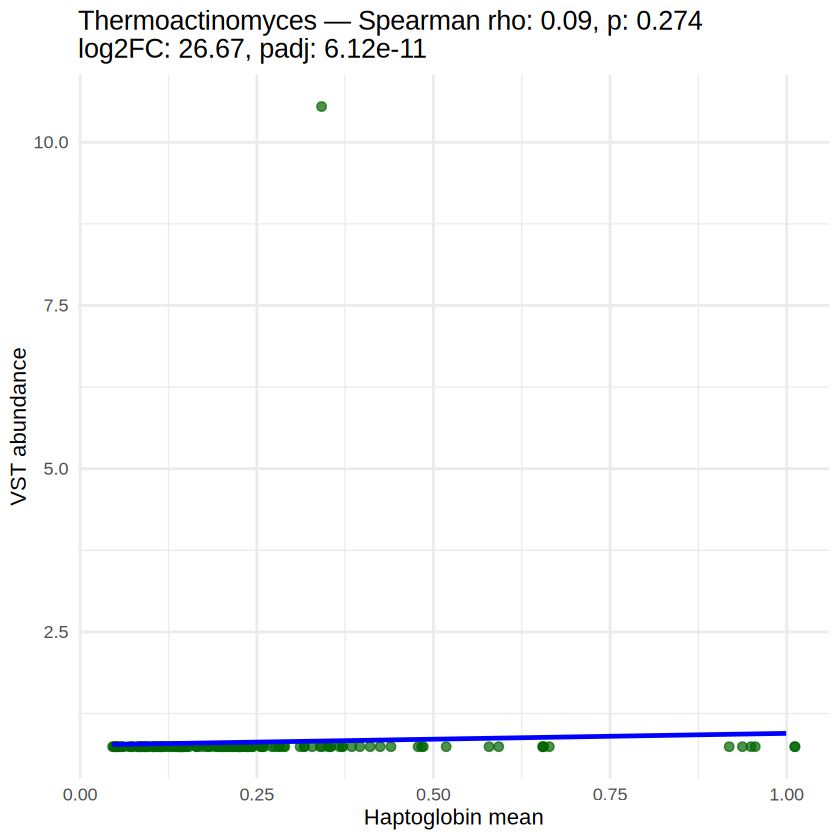

`geom_smooth()` using formula = 'y ~ x'


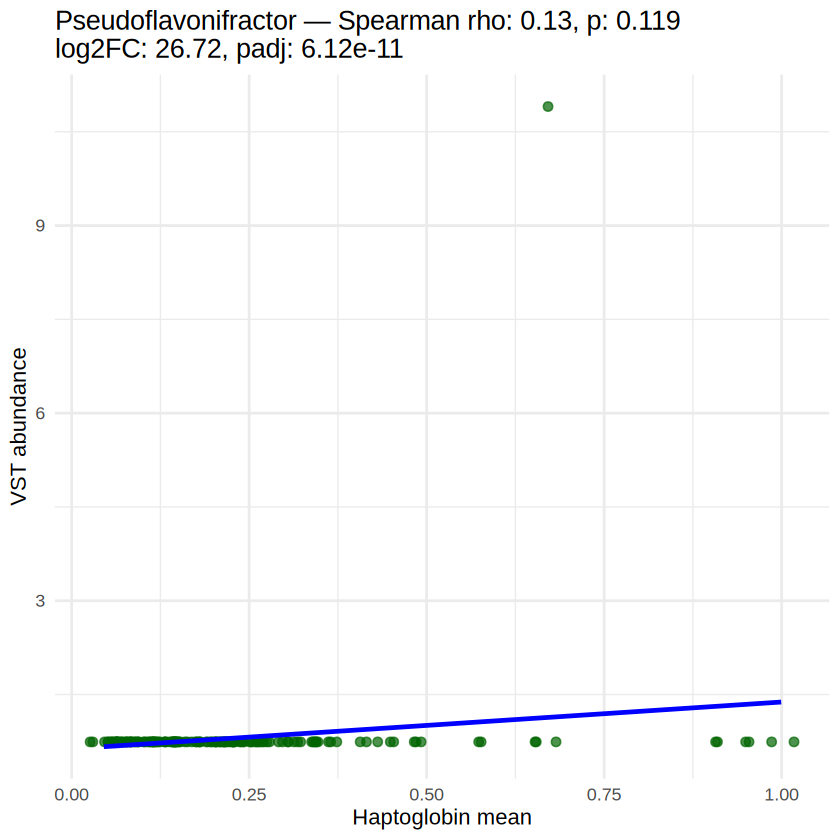

`geom_smooth()` using formula = 'y ~ x'


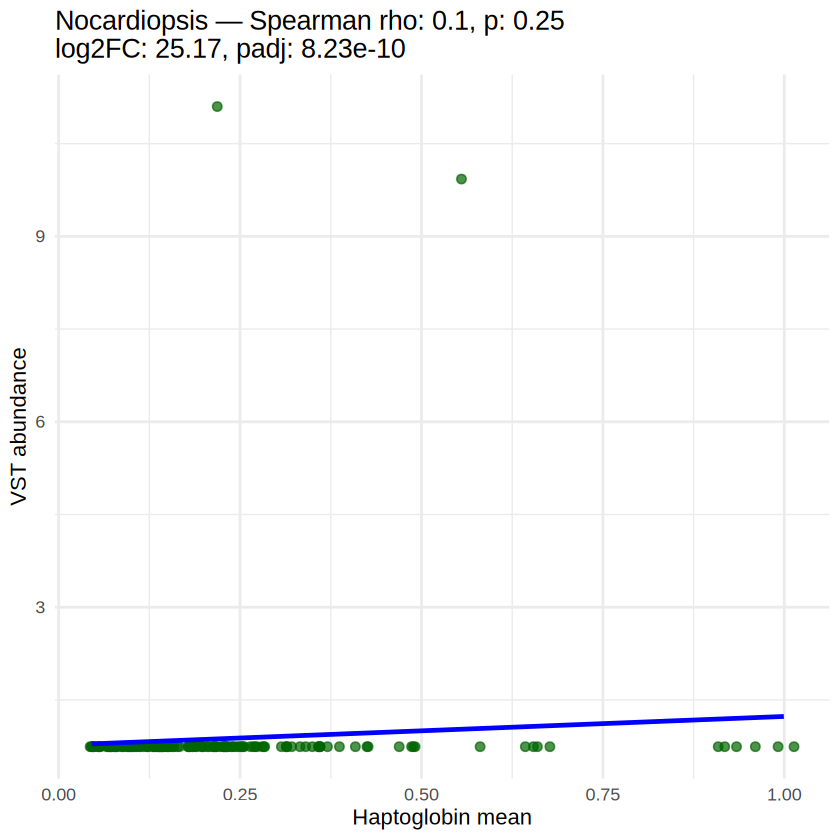

`geom_smooth()` using formula = 'y ~ x'


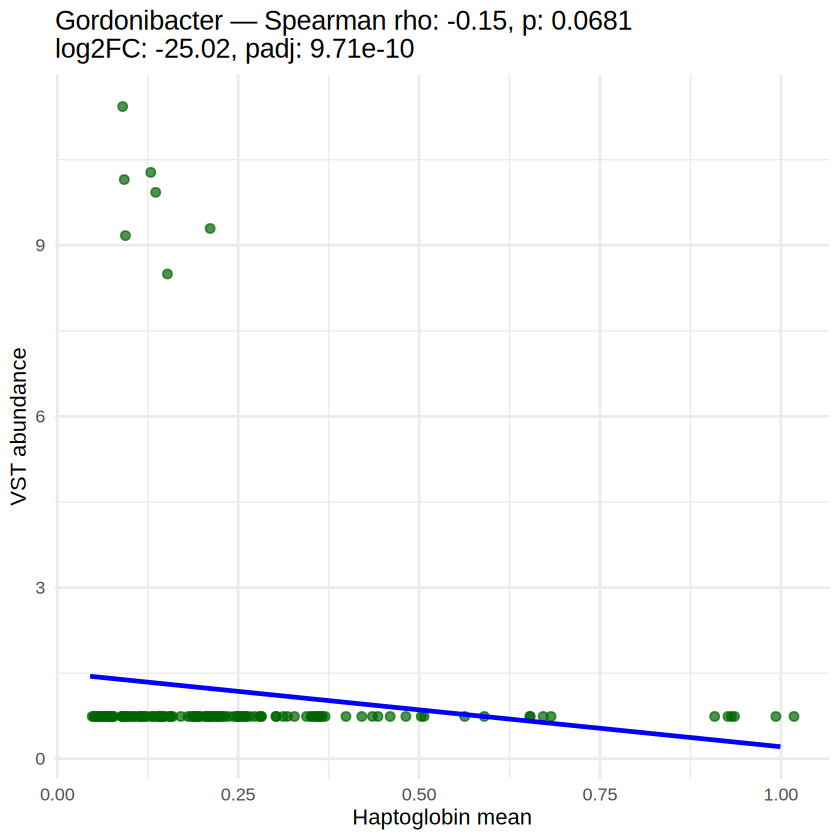

`geom_smooth()` using formula = 'y ~ x'


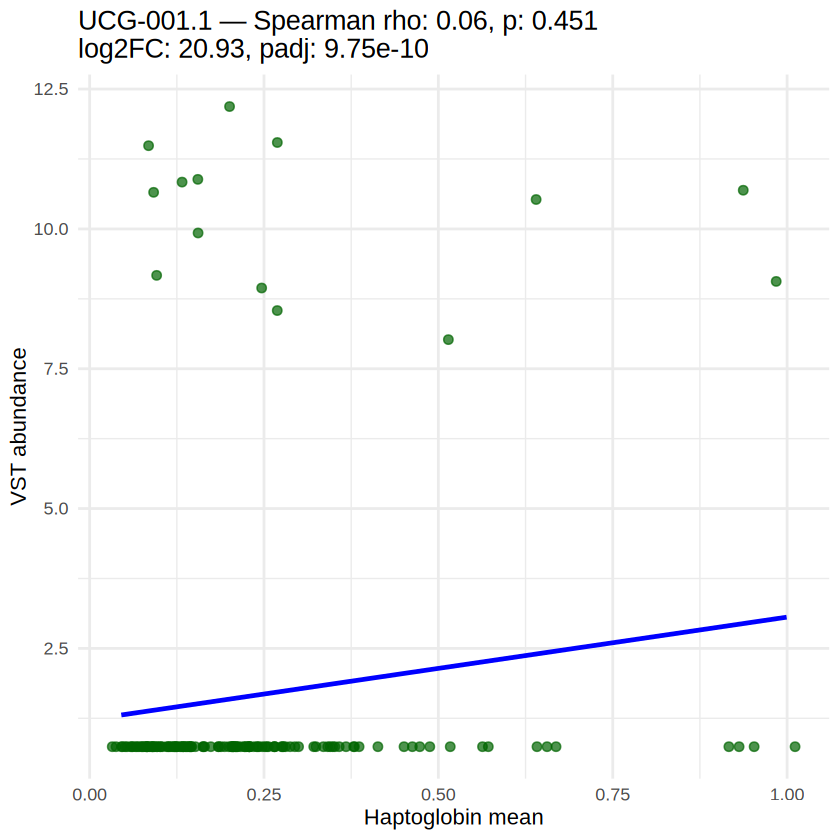

`geom_smooth()` using formula = 'y ~ x'


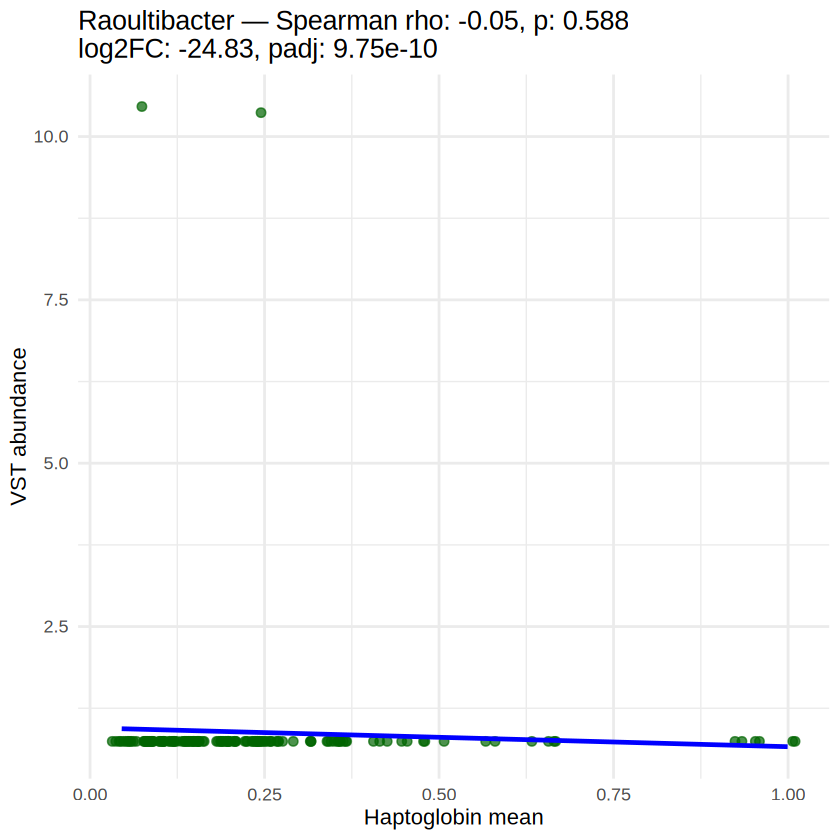

`geom_smooth()` using formula = 'y ~ x'


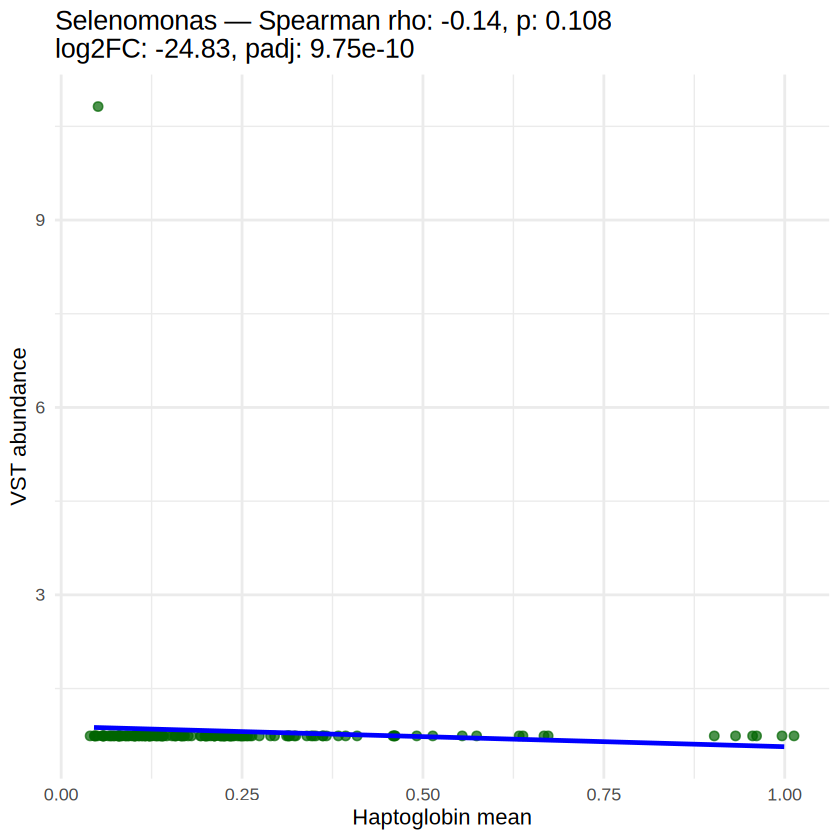

`geom_smooth()` using formula = 'y ~ x'


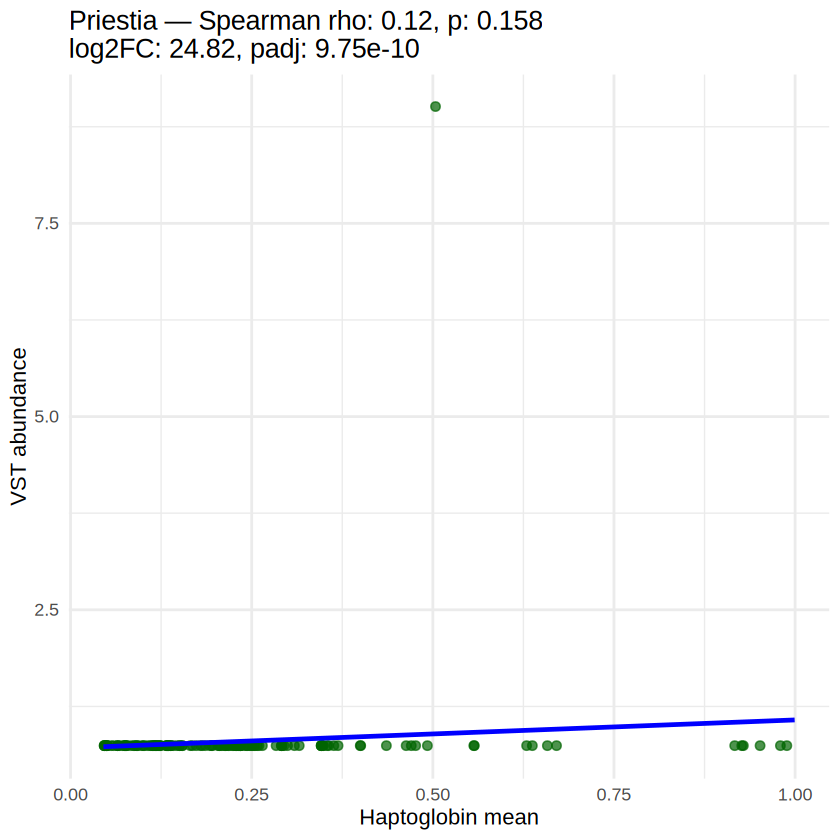

`geom_smooth()` using formula = 'y ~ x'


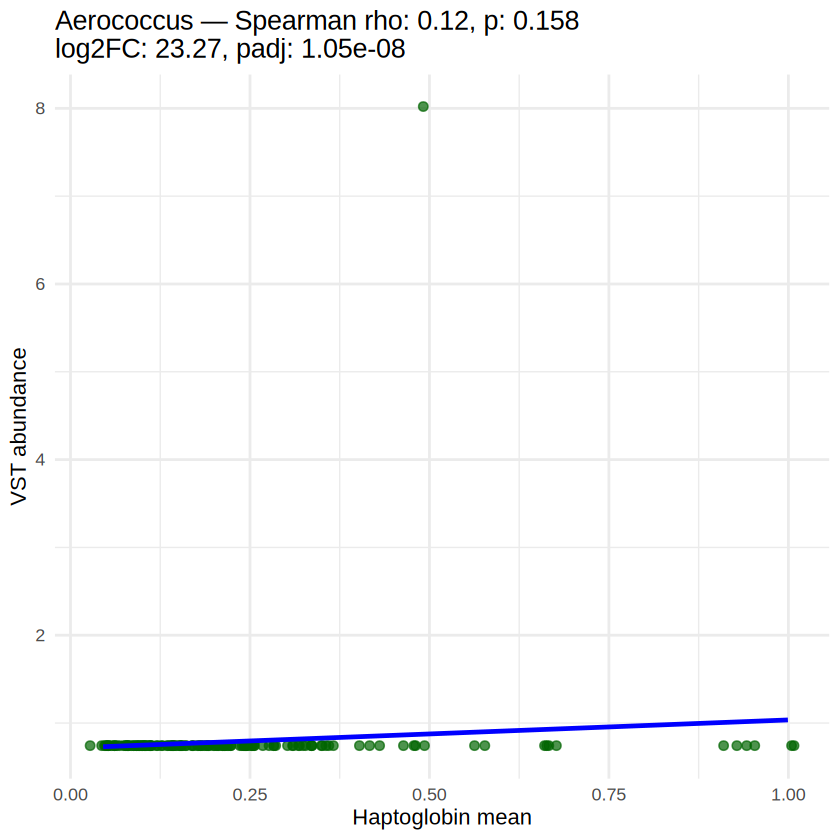

`geom_smooth()` using formula = 'y ~ x'


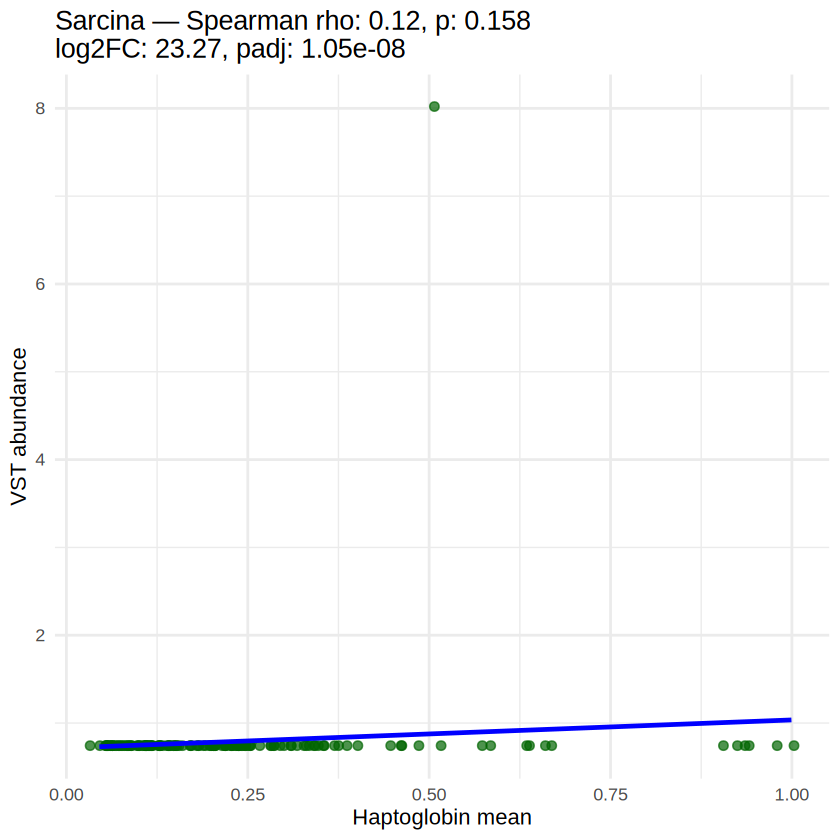

`geom_smooth()` using formula = 'y ~ x'


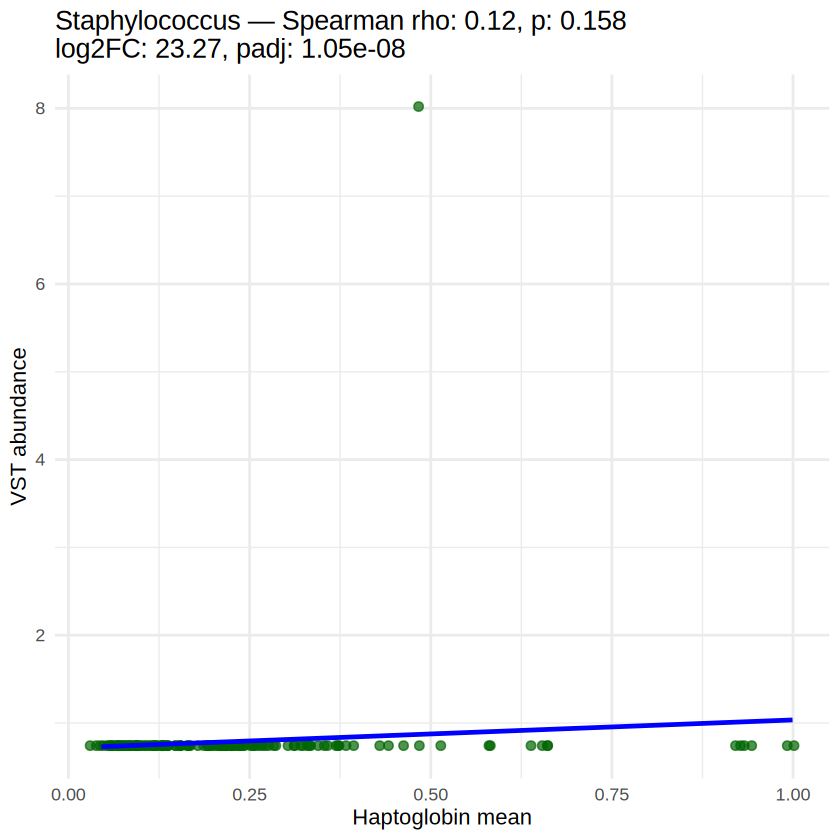

`geom_smooth()` using formula = 'y ~ x'


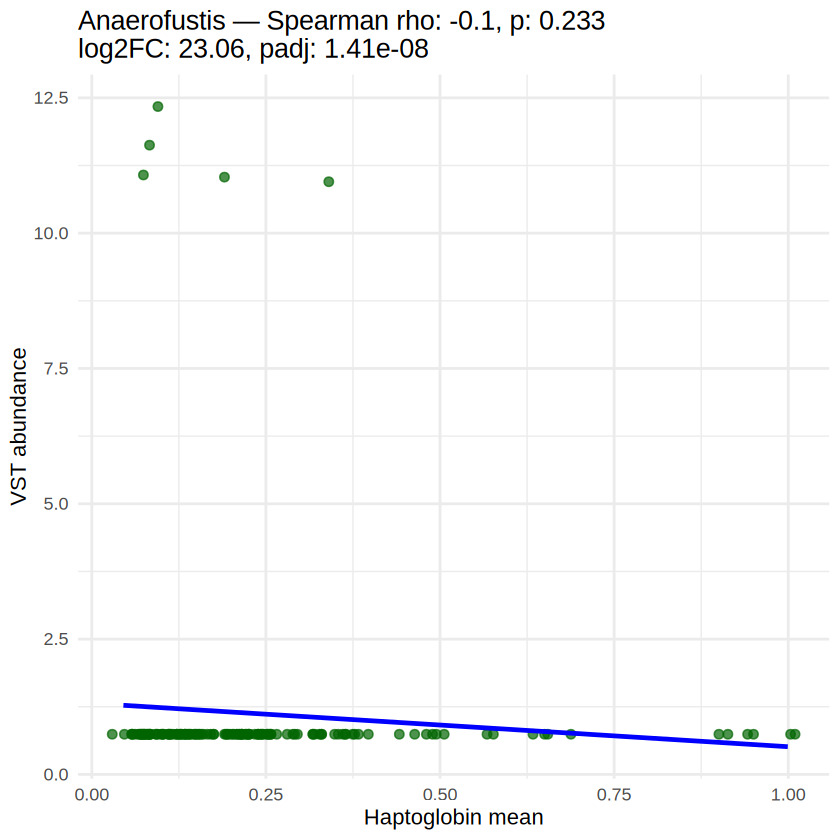

`geom_smooth()` using formula = 'y ~ x'


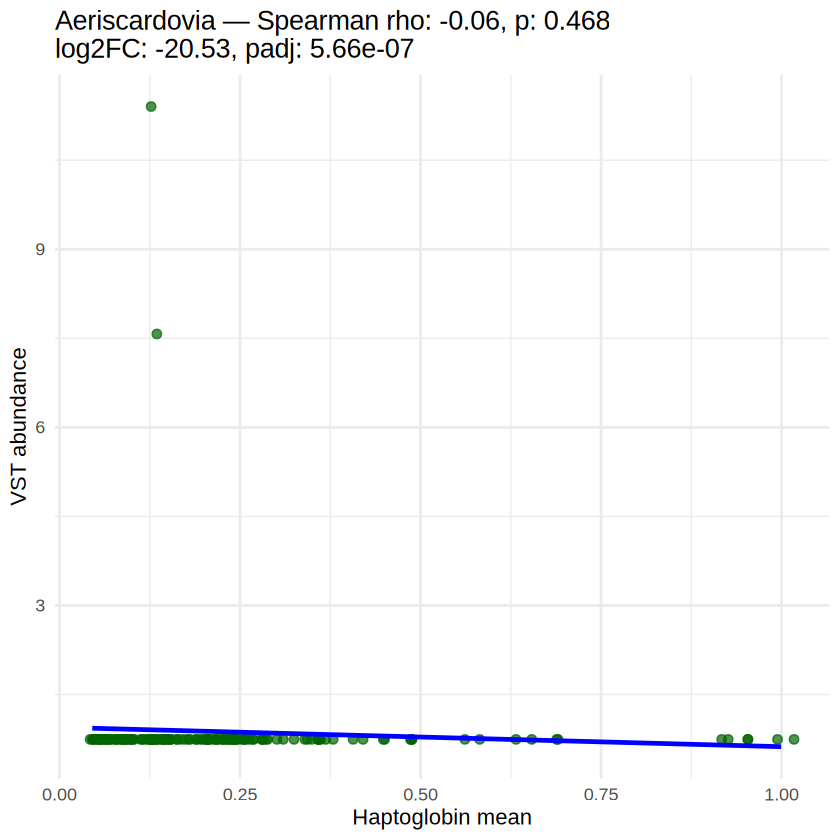

`geom_smooth()` using formula = 'y ~ x'


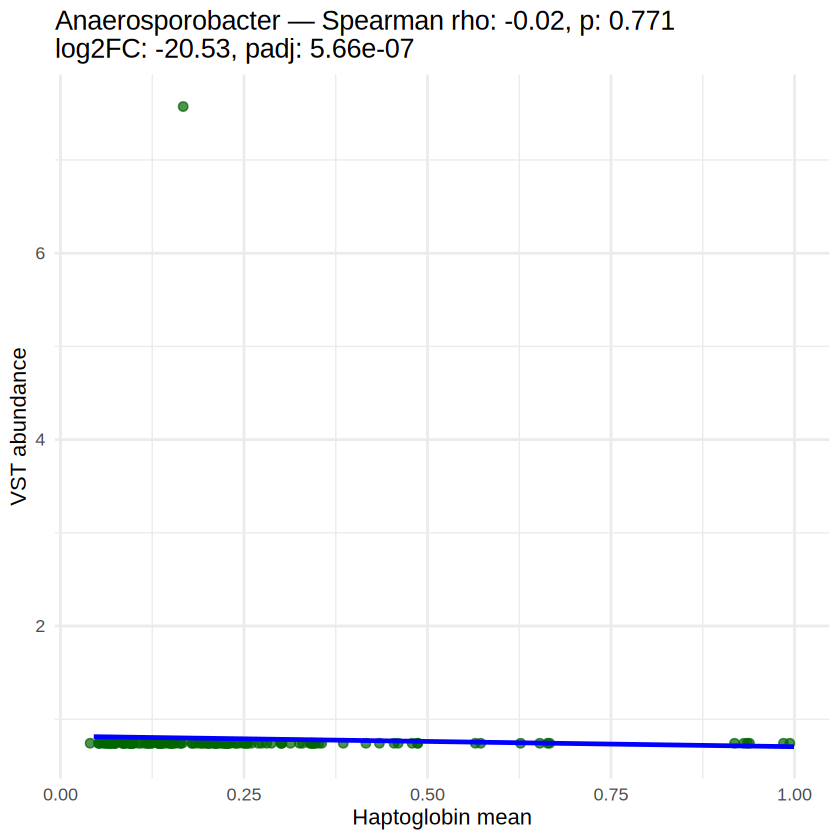

`geom_smooth()` using formula = 'y ~ x'


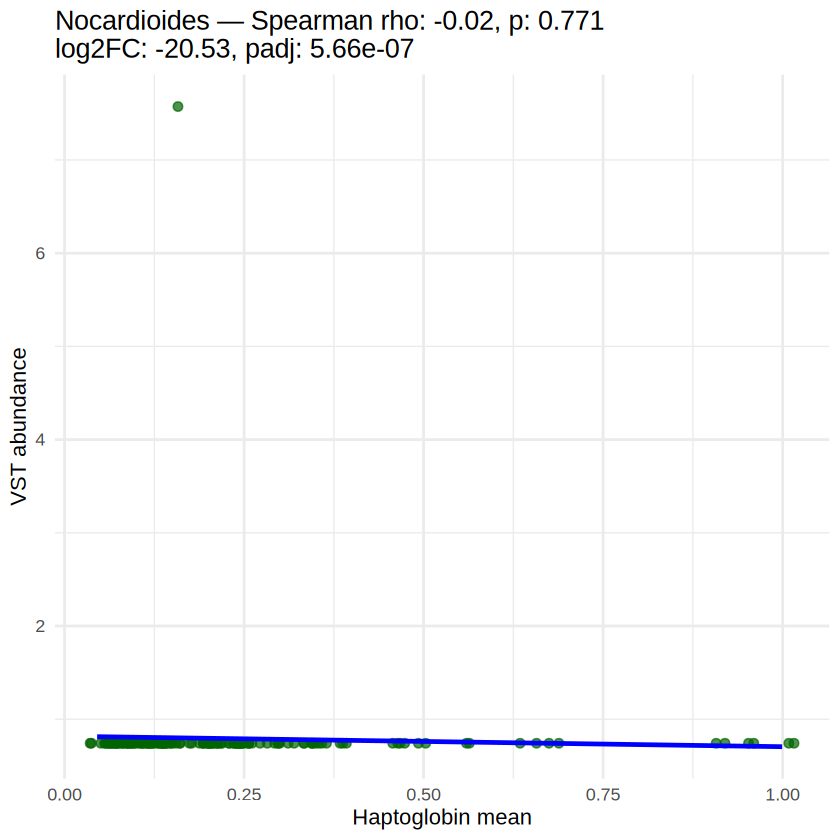

`geom_smooth()` using formula = 'y ~ x'


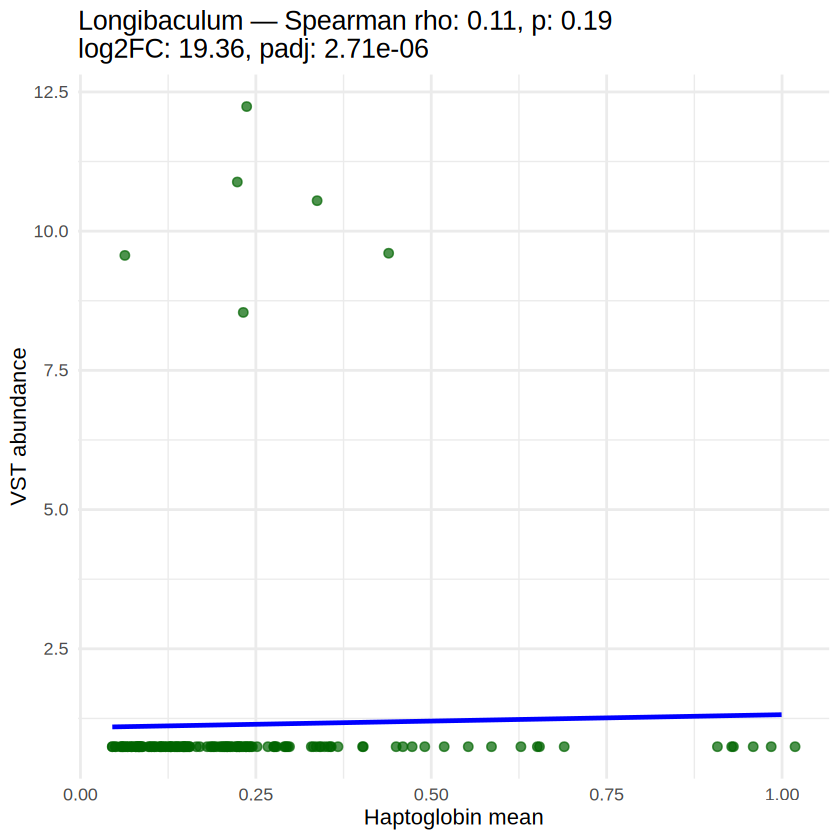

`geom_smooth()` using formula = 'y ~ x'


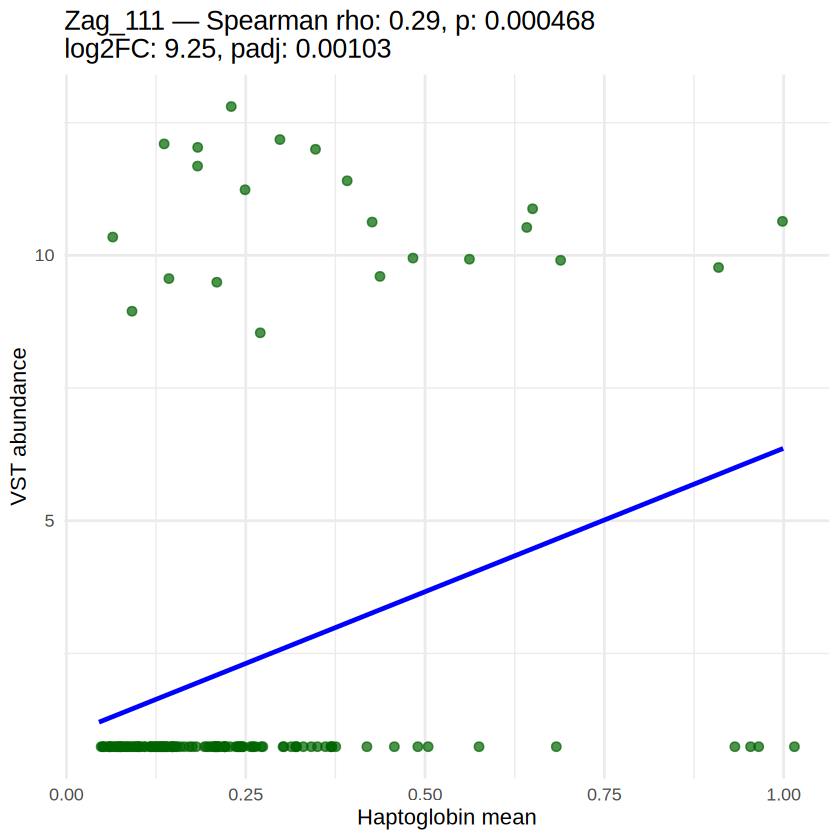

`geom_smooth()` using formula = 'y ~ x'


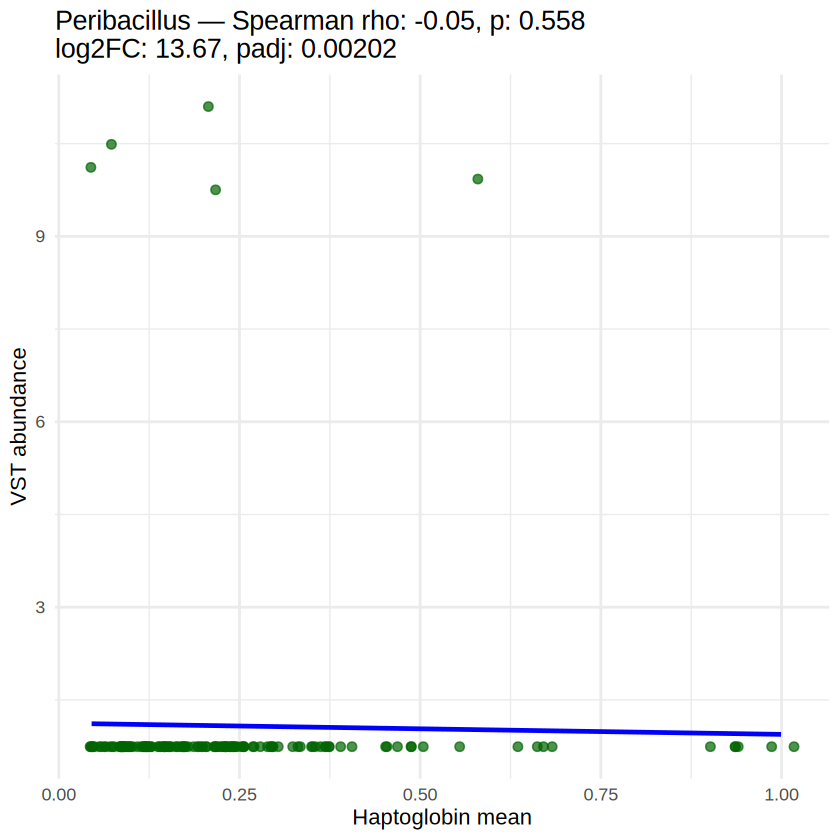

`geom_smooth()` using formula = 'y ~ x'


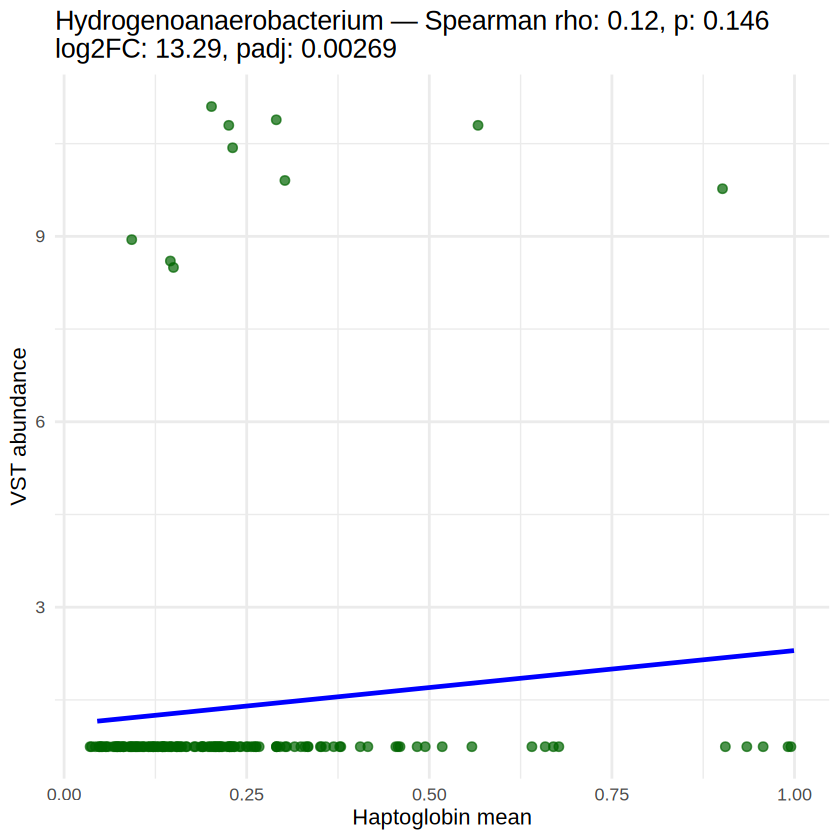

`geom_smooth()` using formula = 'y ~ x'


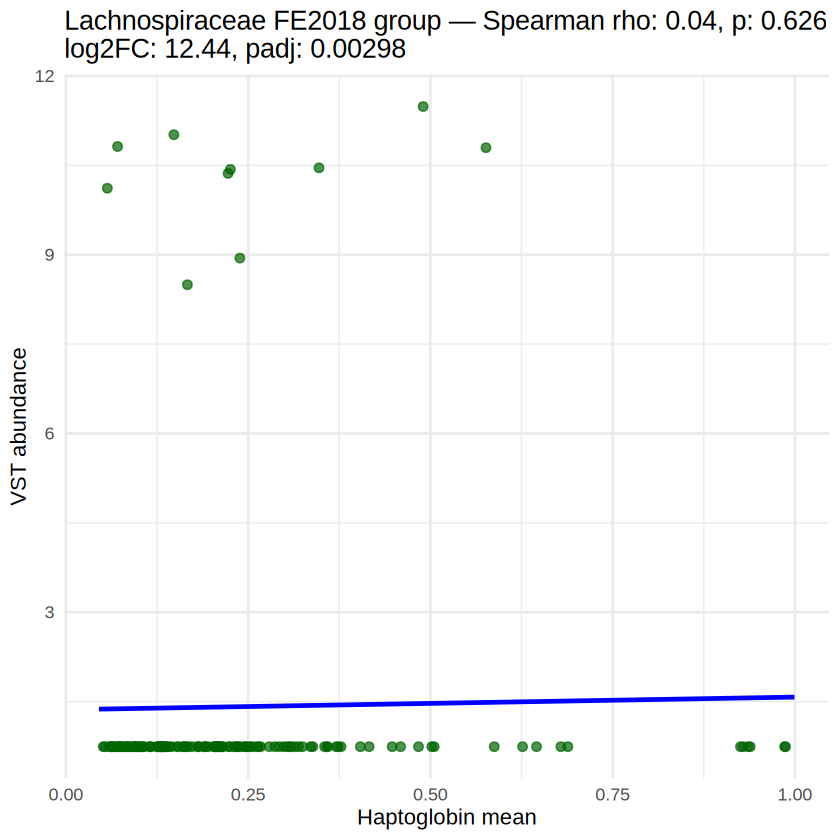

`geom_smooth()` using formula = 'y ~ x'


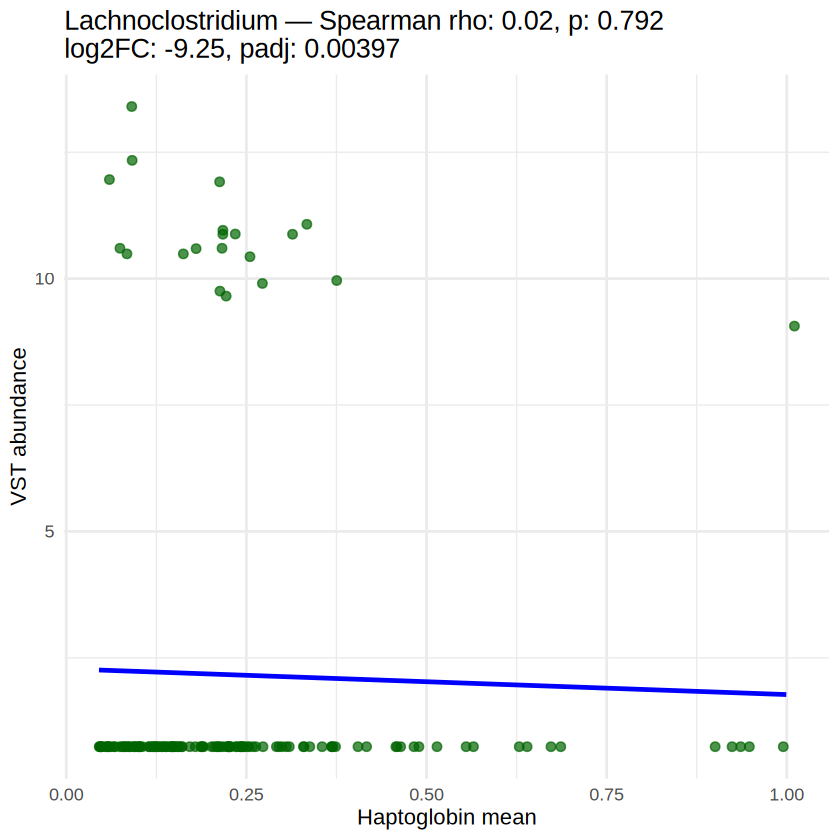

`geom_smooth()` using formula = 'y ~ x'


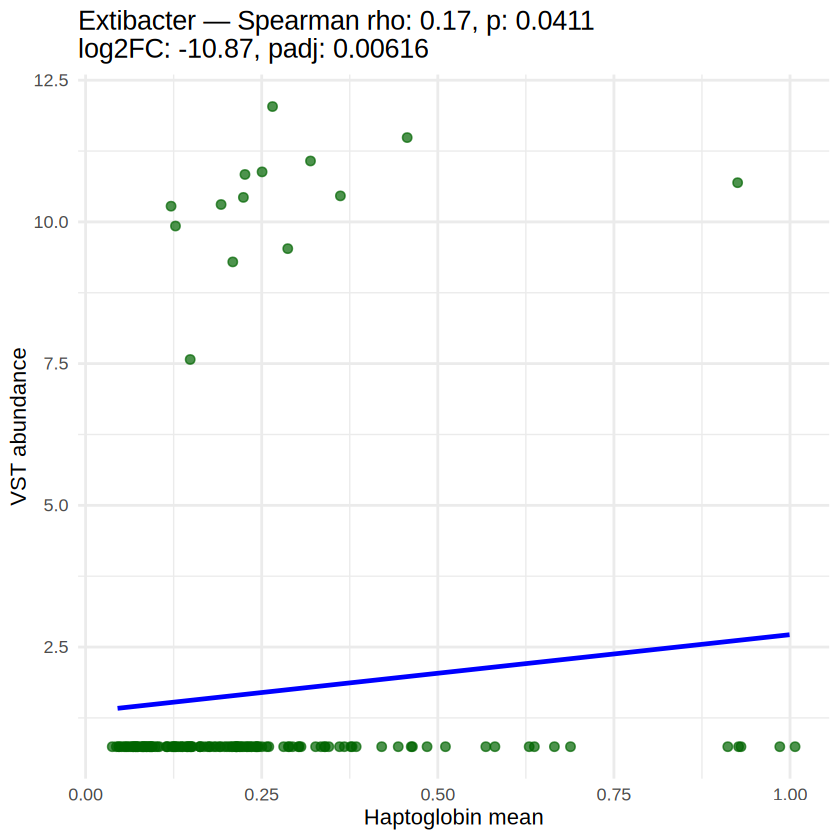

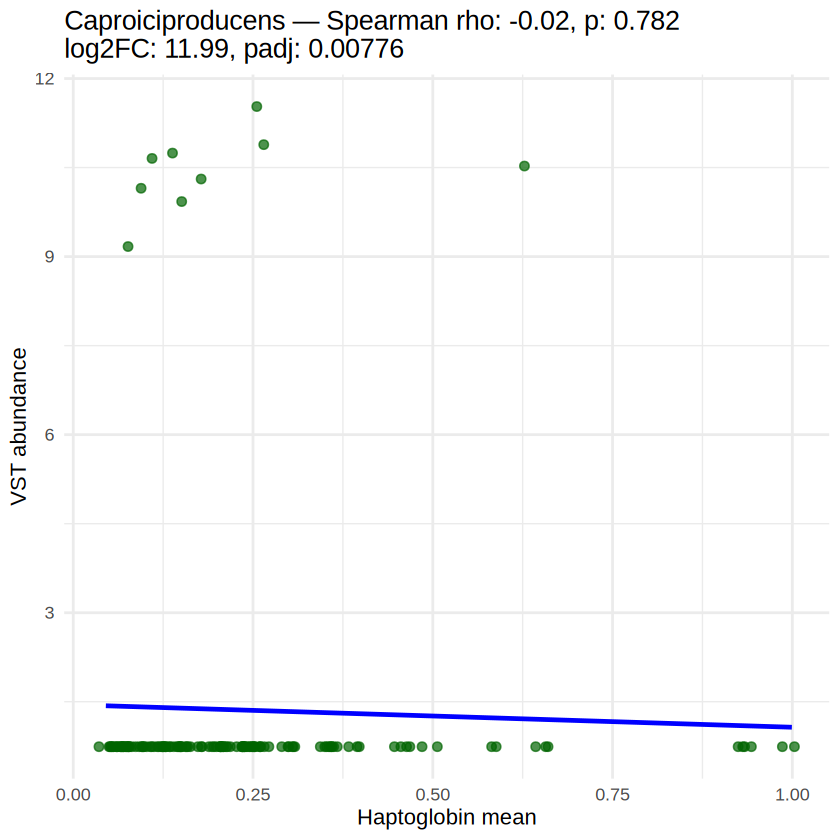

In [187]:
library(ggplot2)

# Make sure samples match
all(colnames(vsd_sig_filtered) == rownames(meta_genus))  # should be TRUE

# Loop over genera
for(genus in rownames(vsd_sig_filtered)){
  
  df_plot <- data.frame(
    Abundance = vsd_sig_filtered[genus, ],
    Haptoglobin = meta_genus$Haptoglobin_Mean
  )
  
  # Remove NAs
  df_plot <- df_plot[complete.cases(df_plot), ]
  
  # Safe Spearman correlation
  if(length(df_plot$Abundance) >= 3 && sd(df_plot$Abundance) != 0){
    ct <- cor.test(df_plot$Abundance, df_plot$Haptoglobin, 
                   method = "spearman", exact = FALSE)
    rho <- round(ct$estimate, 2)
    pval <- signif(ct$p.value, 3)
  } else {
    rho <- NA
    pval <- NA
  }
  
  # Get DESeq2 log2FoldChange for this genus
  lfc <- result_Hapto$log2FoldChange[rownames(result_Hapto) == genus]
  padj <- result_Hapto$padj[rownames(result_Hapto) == genus]
  
  # Scatter / jitter plot
  p <- ggplot(df_plot, aes(x = Haptoglobin, y = Abundance)) +
    geom_jitter(width = 0.02, height = 0, size = 2, alpha = 0.7, color = "darkgreen") +
    geom_smooth(method = "lm", se = FALSE, color = "blue") +
    labs(
      title = paste0(genus, 
                     " — Spearman rho: ", rho, ", p: ", pval,
                     "\nlog2FC: ", round(lfc, 2), ", padj: ", signif(padj, 3)),
      x = "Haptoglobin mean",
      y = "VST abundance"
    ) +
    theme_minimal(base_size = 13)
  
  print(p)
}


In [188]:
library(ggplot2)
library(patchwork)  # for combining plots

plot_list <- list()

for(genus in rownames(vsd_sig_filtered)){
  
  df_plot <- data.frame(
    Abundance = vsd_sig_filtered[genus, ],
    Haptoglobin = meta_genus$Haptoglobin_Mean
  )
  
  df_plot <- df_plot[complete.cases(df_plot), ]
  
  if(length(df_plot$Abundance) >= 3 && sd(df_plot$Abundance) != 0){
    ct <- cor.test(df_plot$Abundance, df_plot$Haptoglobin, method = "spearman", exact = FALSE)
    rho <- round(ct$estimate, 2)
    pval <- signif(ct$p.value, 3)
  } else {
    rho <- NA
    pval <- NA
  }
  
  lfc <- result_Hapto$log2FoldChange[rownames(result_Hapto) == genus]
  padj <- result_Hapto$padj[rownames(result_Hapto) == genus]
  
  p <- ggplot(df_plot, aes(x = Haptoglobin, y = Abundance)) +
    geom_jitter(width = 0.02, height = 0, size = 2, alpha = 0.7, color = "darkgreen") +
    geom_smooth(method = "lm", se = FALSE, color = "blue") +
    labs(
      title = paste0(genus, 
                     " — Spearman rho: ", rho, ", p: ", pval,
                     "\nlog2FC: ", round(lfc, 2), ", padj: ", signif(padj, 3)),
      x = "Haptoglobin mean",
      y = "VST abundance"
    ) +
    theme_minimal(base_size = 13)
  
  # Store in list
  plot_list[[genus]] <- p
}


In [189]:
library(patchwork)

# Combine all plots in 2 columns
combined_plot <- wrap_plots(plot_list, ncol = 2)

# Save combined figure
ggsave("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/Hapto_genus_correlation_combined.png",
       plot = combined_plot, width = 12, height = 18, dpi = 300)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [190]:
for(genus in names(plot_list)){
  ggsave(
    filename = paste0("/scratch/negishi/ldas/COW_INFLAMMATION/Figures/", genus, "_Hapto_corr.svg"),
    plot = plot_list[[genus]],
    width = 5, height = 4,
    device = "svg"
  )
}


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
